# Imports

In [2]:
import os
import utils
import xml.etree.ElementTree as ET
import numpy as np
import matplotlib.pyplot as plt
import ceinms
import openSim
import pandas as pd
import shutil
import opensim as osim

import settings


# Preprocessing

In [ ]:


def copy_input_files(src_session_path, dest_session_path, trial_list):
    """
    Copy necessary input files from source trial to destination trial.
    """
    input_files = [
        'trial_settings.xml','EMG_filtered_normalised.sto','EMG_filtered_normalised_scaled_0.70.sto',
    ]
    
    for trial in trial_list:
        src_trial_path = os.path.join(src_session_path, trial)
        dest_trial_path = os.path.join(dest_session_path, trial)
        
        os.makedirs(dest_trial_path, exist_ok=True)
        
        for file_name in input_files:
            src_file = os.path.join(src_trial_path, file_name)
            dest_file = os.path.join(dest_trial_path, file_name)
            if os.path.exists(src_file):
                shutil.copy2(src_file, dest_file)
                print(f"Copied {src_file} to {dest_file}")
            else:
                print(f"Warning: {src_file} does not exist and was not copied.")

src_session = os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31')
dest_session = os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_Lernagopal_optimised', '25_03_31')
trials_to_copy = ['Squat_bw_01']

copy_input_files(src_session, dest_session, trials_to_copy)

In [ ]:
folder_path = r"C:\Git\powerlifing_model_clean\simulations\pilot_01\09-03-2026"

grouped_root = os.path.join(folder_path, "_grouped_by_name")
os.makedirs(grouped_root, exist_ok=True)

files_by_stem = {}

for current_root, dirs, files in os.walk(folder_path):
    dirs[:] = [d for d in dirs if os.path.abspath(os.path.join(current_root, d)) != os.path.abspath(grouped_root)]

    if os.path.abspath(current_root).startswith(os.path.abspath(grouped_root)):
        continue

    for file_name in files:
        stem, ext = os.path.splitext(file_name)
        files_by_stem.setdefault(stem, []).append(os.path.join(current_root, file_name))

matched_groups = 0

for stem, file_paths in files_by_stem.items():
    if len(file_paths) < 2:
        continue

    matched_groups += 1
    target_folder = os.path.join(grouped_root, stem)
    os.makedirs(target_folder, exist_ok=True)

    for src_path in file_paths:
        rel_dir = os.path.relpath(os.path.dirname(src_path), folder_path)

        if rel_dir == ".":
            dest_name = os.path.basename(src_path)
        else:
            dest_name = f"{rel_dir.replace(os.sep, '__')}__{os.path.basename(src_path)}"

        dest_path = os.path.join(target_folder, dest_name)
        shutil.copy2(src_path, dest_path)
        print(f"Copied: {src_path} -> {dest_path}")

print(f"Done. Found {matched_groups} filename groups with matching stems.")
print(f"Grouped files saved in: {grouped_root}")

In [ ]:
source_folder  = r"D:\3-PhD\Data\MocapData\ElaboratedData"
destination_folder = r"C:\Git\research_data\Projects\runbops_FAIS_phd\simulations"

subjects = os.listdir(source_folder)

for subject in subjects:
    static_folder = os.path.join(source_folder, subject, "pre", "staticElaborations")
    scale_folder = os.path.join(source_folder, subject, "pre", "Scale")

    if not os.path.exists(static_folder):
        continue

    # copy static to destination folder
    dest_subject_folder = os.path.join(destination_folder, subject, "pre", "static")

    os.makedirs(dest_subject_folder, exist_ok=True)
    
    src_file = os.path.join(static_folder, 'static1.trc')
    dest_file = os.path.join(dest_subject_folder, 'static1.trc')
    try:
        shutil.copy2(src_file, dest_file)
        print(f"Copied {src_file} to {dest_file}")
    except FileNotFoundError:
        print(f"Warning: {src_file} does not exist and was not copied.")


    src_file = os.path.join(scale_folder, 'Setup_Scale.xml')
    dest_file = os.path.join(dest_subject_folder, 'Setup_Scale.xml')
    try:
        shutil.copy2(src_file, dest_file)
        print(f"Copied {src_file} to {dest_file}")

        # edit the tag marker_file to be simply "static1.trc"
        
    except FileNotFoundError:
        print(f"Warning: {src_file} does not exist and was not copied.")


In [ ]:
xml_path = r"C:\Users\Basilio\ucloud\Forschungspraktikum\Danijel Milovanovic\repeated_sprinting\Simulations\012\pre\static\Setup_Scale.xml"
tag = 'marker_file'
new_value = 'static1.trc'

tree = ET.parse(xml_path)
root = tree.getroot()

elem_list = root.findall(f".//{tag}")

if elem_list:
    for elem in elem_list:
        elem.text = str(new_value)
    utils.save_pretty_xml(tree, xml_path)  # Save back to the original file
    print(f"Updated tag '{tag}' to new value: {new_value}")
else:
    print(f"Error: Tag '{tag}' not found in the XML tree.")

In [ ]:
trc_file = r"C:\Users\Basilio\ucloud\Forschungspraktikum\Danijel Milovanovic\repeated_sprinting\Simulations\012\pre\static\static1.trc"

trc_data = utils.load_any_data_file(trc_file)
print(trc_data)
if os.path.exists(trc_file):
    print(f"File exists: {trc_file}")

utils.write_trc(trc_data, trc_file.replace(".trc", "_copy.trc"), units='mm', frame_rate=100, first_frame=1)

# Export session c3d

In [ ]:
subject = 'HC835B' 
session = 'Session1' # '25_03_31' '22_07_06' walking 09-03-2026

files_session = os.listdir(os.path.join(utils.SIMULATIONS_DIR, subject, session))

for file in files_session:
    if file.endswith('.c3d'):
        openSim.export_c3d(c3d_file_path=os.path.join(utils.SIMULATIONS_DIR, subject, session, file))

# Single trial analysis

## Initiate trial

In [3]:
subject = 'HC835B' # 'Athlete_03', 'Athlete_03_MRI_BG'  'Athlete_03_MRI_Katya' Athlete_03_Lernagopal Athlete_03_Lernagopal_optimised Athlete_03_GPK Athlete_03_Uhlrich 
session = 'Session1' # '25_03_31' '22_07_06' walking 09-03-2026
trial = 'HC835B_OGR_0001'  # 'Walking_02', 'Squat_35kg_01', 'Squat_bw_01'

trialPath = os.path.join(utils.SIMULATIONS_DIR, subject, session, trial) # Walking_02, Squat_bw_01, Squat_35kg_01
print(f'Analyzing trial at path: {trialPath}')

analysis = utils.Analyse(trialPath)
# analysis.reset_settings_xml()

analysis._update_model()
analysis._update_emg_tag()

print("Main inputs:")
print(f"Model file: {analysis.model_dir}")
print(f"time range: {analysis.time_range}")

analysis.update_trial_attribute('ceinms_calibration_trials', ['HC835B_OGR_0001'])
analysis.update_trial_attribute('Target_Muscles', 'all')
analysis.delete_trial_attribute('EMG_muscle_mapping')
analysis.delete_trial_attribute('Objective_Functions')


# open settings.xml in the editor
settings_xml_path = os.path.join(trialPath, 'trial_settings.xml')
os.startfile(settings_xml_path)

Analyzing trial at path: c:\Git\powerlifing_model_clean\simulations\HC835B\Session1\HC835B_OGR_0001
Settings loaded from: c:\Git\powerlifing_model_clean\simulations\HC835B\Session1\HC835B_OGR_0001\trial_settings.xml
Trial settings saved to: c:\Git\powerlifing_model_clean\simulations\HC835B\Session1\HC835B_OGR_0001\trial_settings.xml
Trial settings saved to: c:\Git\powerlifing_model_clean\simulations\HC835B\Session1\HC835B_OGR_0001\trial_settings.xml
Trial settings saved to: c:\Git\powerlifing_model_clean\simulations\HC835B\Session1\HC835B_OGR_0001\trial_settings.xml
Main inputs:
Model file: ..\..\..\..\models\HC835B\Session1\GPK_generic_Lukas_scaled.osim
time range: [0.0041666666666666, 0.8833333333333333]
Trial settings saved to: c:\Git\powerlifing_model_clean\simulations\HC835B\Session1\HC835B_OGR_0001\trial_settings.xml
Trial settings saved to: c:\Git\powerlifing_model_clean\simulations\HC835B\Session1\HC835B_OGR_0001\trial_settings.xml
Trial settings saved to: c:\Git\powerlifing_mo

## Delete output files

In [ ]:
analysis._remove_outputs()

analysis = utils.Analyse(trialPath)

In [ ]:
# check if files in analysis actually exist
for atrr in analysis.__dict__:
    atrr_value = getattr(analysis, atrr)

    try:
        if os.path.exists(os.path.join(analysis.path, atrr_value)):
            print(f'{atrr}: {os.path.join(analysis.path, atrr_value)}')
        else:
            print(f'{atrr}: {atrr_value}')
    except Exception as e:
        print(f'Warning not path ({atrr}): {atrr_value}')


In [ ]:
analysis.time_range = analysis.get_time_range()
analysis._to_xml()
print(analysis.time_range)

## reload settings

In [ ]:
analysis.load_settings(analysis.settingsXML)
print(f'{analysis.model_dir}')

## Copy files from template subject 

In [ ]:
analysis.copy_input_files('Athlete_03', replace=False) # assume both subjects contain same session and trial names

## Reset settings

In [ ]:
analysis.reset_settings_xml()

## Add markerkerset to model

In [ ]:
def add_markers_to_model(source_model_path, target_model_path, output_model_path):
    # Load the model
    model = openSim.osim.Model(source_model_path)
    
    target_model = openSim.osim.Model(target_model_path)
    model.setName(target_model.getName())  # Set the name of the new model to match the target model    
    # Get marker sets
    source_marker_set = model.updMarkerSet() if hasattr(model, "updMarkerSet") else model.getMarkerSet()
    target_marker_set = target_model.getMarkerSet()

    # Track existing marker names to avoid duplicates
    existing_markers = {source_marker_set.get(i).getName() for i in range(source_marker_set.getSize())}

    added_count = 0
    for i in range(target_marker_set.getSize()):
        marker = target_marker_set.get(i)
        marker_name = marker.getName()

        if marker_name in existing_markers:
            continue

        source_marker_set.cloneAndAppend(marker)
        existing_markers.add(marker_name)
        added_count += 1

    # Finalize and save
    model.finalizeConnections()
    model.printToXML(output_model_path)

    print(f"Added {added_count} markers.")
    print(f"Saved model: {output_model_path}")
    return output_model_path

source_model_path = r"C:\Git\powerlifing_model_clean\models\Catelli_high_hip_Flexion_V4.0\Catelli-V4.0_PowerliftingMarkers.osim"
target_model_path = r"C:\Git\powerlifing_model_clean\models\Athlete_03_Uhrich\25_03_31\Rajagopal2015_passiveCal_hipAbdMoved.osim"
add_markers_to_model(source_model_path, target_model_path, target_model_path.replace('.osim', '_with_markers.osim'))

## scale tool

In [ ]:
marker_map = {
        "pelvis": {"LASI": "LASI", "RASI": "RASI", "LPSI": "LPSI", "RPSI": "RPSI"},
        "knee_r_pairs": [("RLFC", "RMFC"), ("RKNE", "RKNM"), ("RKNE", "RKNI"), ("RLK", "RMK")],
        "knee_l_pairs": [("LLFC", "LMFC"), ("LKNE", "LKNM"), ("LKNE", "LKNI"), ("LLK", "LMK")],
        "ankle_r_pairs": [("RANK", "RMED"), ("RANK", "RANM"), ("RANK", "RANKM"), ("RLA", "RMA")],
        "ankle_l_pairs": [("LANK", "LMED"), ("LANK", "LANM"), ("LANK", "LANKM"), ("LLA", "LMA")],
        "existing_hip_r": ["RHJC", "RHIP"],
        "existing_hip_l": ["LHJC", "LHIP"],
    }
input_trc =os.path.join(utils.SIMULATIONS_DIR, subject, session, 'static', 'static1.trc')
output_trc = openSim.add_joint_centres_to_trc(input_trc, marker_map=marker_map)


In [ ]:
static_trial = 'Static_01'

generic_model = os.path.join(utils.MODELS_DIR, subject, session, 'tps_transformed.osim')
setup_xml     = os.path.join(utils.SIMULATIONS_DIR, subject, session, static_trial, 'setup_scale.xml')
static_trc    = os.path.join(utils.SIMULATIONS_DIR, subject, session, static_trial, 'marker_experimental_with_JointCenters.trc')
scaled_model  = os.path.join(utils.MODELS_DIR, subject, session, 'tps_transformed_scaled.osim')

scale_tool = openSim.scale_model_from_xml(setup_xml_path=setup_xml, generic_model_path=generic_model, static_trc_path=static_trc, scaled_model_path=scaled_model, mass=analysis.body_mass)

## Export C3D

In [ ]:
openSim.export_c3d(c3d_file_path=os.path.join(utils.SIMULATIONS_DIR, subject, session, trial + '.c3d'))

## Event Detection

In [ ]:

import numpy as np
import pandas as pd
from scipy.signal import find_peaks

class EventDetector:
    """
    A task-specific event detector that reads .trc and .mot files natively.
    Synchronizes high-frequency GRF data with lower-frequency kinematic data using time stamps.
    """

    def __init__(self, grf_threshold: float = 20.0, vertical_axis: str = 'Y'):
        """
        Args:
            grf_threshold (float): Threshold in Newtons to define ground contact.
            vertical_axis (str): The vertical axis in your lab's coordinate system ('Y' or 'Z').
                                 OpenSim conventionally uses 'Y' as up.
        """
        self.grf_threshold = grf_threshold
        self.vertical_axis = vertical_axis.upper()

    def _read_mot(self, file_path: str) -> pd.DataFrame:
        """Parses OpenSim .mot files (GRF and Joint Angles)."""
        skip_rows = 0
        with open(file_path, 'r') as f:
            for i, line in enumerate(f):
                if line.strip() == 'endheader':
                    skip_rows = i + 1
                    break
        return pd.read_csv(file_path, sep='\t', skiprows=skip_rows)

    def _read_trc(self, file_path: str) -> pd.DataFrame:
        """Parses standard .trc marker trajectory files."""
        with open(file_path, 'r') as f:
            lines = f.readlines()
        
        # Marker names are typically located on the 4th line (index 3)
        header_line = lines[3].strip('\n').split('\t')
        marker_names = [m for m in header_line[2:] if m.strip()]
        
        cols = ['Frame', 'Time']
        for m in marker_names:
            cols.extend([f"{m}_X", f"{m}_Y", f"{m}_Z"])
            
        df = pd.read_csv(file_path, sep='\t', skiprows=5, header=None)
        # Trim excess columns if trailing tabs existed in the raw file
        df = df.iloc[:, :len(cols)]
        df.columns = cols
        return df

    def analyze_task(self, trc_file: str, grf_file: str, kinematics_file: str, task: str) -> dict:
        """
        Main entry point. Loads the required files into DataFrames and routes 
        them to the specific task analyzer.
        Args:
            trc_file (str): Path to the .trc file containing marker trajectories.
            grf_file (str): Path to the .mot file containing ground reaction forces.
            kinematics_file (str): Path to the .mot file containing joint kinematics.
            task (str): 'walking', 'squatting', or 'jumping' (case-insensitive)
        
        Returns:
            dict: A dictionary containing detected events and relevant kinematic/GRF data for the specified task.
        """
        # 1. Load the three mandatory files
        trc_df = self._read_trc(trc_file)
        grf_df = self._read_mot(grf_file)
        kin_df = self._read_mot(kinematics_file) # Always loaded per requirements
        
        task = task.lower()
        
        # Extract total vertical GRF (Assumes OpenSim standard where '_vy' is vertical)
        vy_cols = [c for c in grf_df.columns if 'force' in c and c.endswith(f'_v{self.vertical_axis.lower()}')]
        if not vy_cols:
            raise ValueError(f"Could not find vertical force columns ending in '_v{self.vertical_axis.lower()}'")
        vertical_grf = grf_df[vy_cols].sum(axis=1).values

        # 2. Route to Task Logic
        if task == 'walking':
            return self._analyze_walking(trc_df, grf_df, vertical_grf)
        elif task == 'squatting':
            return self._analyze_squatting(trc_df)
        elif task == 'jumping':
            return self._analyze_jumping(trc_df, grf_df, vertical_grf)
        else:
            raise ValueError(f"Task '{task}' is not recognized.")

    def _analyze_walking(self, trc_df: pd.DataFrame, grf_df: pd.DataFrame, vertical_grf: np.ndarray) -> dict:
        """
        Walking: Uses GRF rising edge for Heel Strike. 
        Checks the RHEE and LHEE marker vertical positions at the moment of impact 
        to classify right vs. left leg strikes.
        """
        grf_time = grf_df['time'].values
        contact = (vertical_grf > self.grf_threshold).astype(int)
        transitions = np.diff(contact)
        
        # Events based on GRF Time
        hs_times = grf_time[np.where(transitions == 1)[0] + 1]
        to_times = grf_time[np.where(transitions == -1)[0] + 1]
        
        # Classify Right/Left based on which foot marker is lower at Heel Strike
        right_hs, left_hs = [], []
        trc_time = trc_df['Time'].values
        
        r_heel_v = trc_df[f'RHEE_{self.vertical_axis}'].values
        l_heel_v = trc_df[f'LHEE_{self.vertical_axis}'].values
        
        for t in hs_times:
            # Find the closest frame in the lower-frequency TRC data
            closest_trc_idx = np.argmin(np.abs(trc_time - t))
            
            if r_heel_v[closest_trc_idx] < l_heel_v[closest_trc_idx]:
                right_hs.append(t)
            else:
                left_hs.append(t)

        return {
            'heel_strike_times': hs_times,
            'toe_off_times': to_times,
            'right_heel_strike_times': np.array(right_hs),
            'left_heel_strike_times': np.array(left_hs)
        }

    def _analyze_squatting(self, trc_df: pd.DataFrame) -> dict:
        """
        Squatting: Uses ONLY Pelvis markers (SACR) to find the bottom of the squat, 
        and calculates vertical velocities/accelerations to define movement phases.
        """
        breakpoint()
        time = trc_df['Time'].values
        dt = time[1] - time[0]
        
        # Average the Sacrum markers to find the true pelvis center
        sacrum_cols = [c for c in trc_df.columns if 'SACR' in c and c.endswith(f'_{self.vertical_axis}')]
        if not sacrum_cols:
            raise ValueError("Squatting analysis requires 'SACR' markers in the TRC file.")
            
        pelvis_v = trc_df[sacrum_cols].mean(axis=1).values
        
        # 1. Find the bottom of the squat (Invert signal to find peak)
        inverted_pelvis = -pelvis_v
        # Prominence of 50 units (mm) to avoid noise being counted as a squat
        bottom_indices, _ = find_peaks(inverted_pelvis, prominence=50.0) 
        
        # 2. Derive Kinematics
        velocity = np.gradient(pelvis_v, dt)
        acceleration = np.gradient(velocity, dt)
        
        return {
            'squat_bottom_times': time[bottom_indices],
            'pelvis_vertical_velocity': velocity,
            'pelvis_vertical_acceleration': acceleration,
            'trc_time_array': time
        }

    def _analyze_jumping(self, trc_df: pd.DataFrame, grf_df: pd.DataFrame, vertical_grf: np.ndarray) -> dict:
        """
        Jumping: Uses GRF to find Take-off and Landing times. 
        Uses Pelvis markers to calculate the apex (max height) of the jump during flight.
        """
        grf_time = grf_df['time'].values
        trc_time = trc_df['Time'].values
        
        contact = (vertical_grf > self.grf_threshold).astype(int)
        transitions = np.diff(contact)
        
        take_off_times = grf_time[np.where(transitions == -1)[0] + 1]
        landing_times = grf_time[np.where(transitions == 1)[0] + 1]
        
        sacrum_cols = [c for c in trc_df.columns if 'SACR' in c and c.endswith(f'_{self.vertical_axis}')]
        pelvis_v = trc_df[sacrum_cols].mean(axis=1).values
        
        apex_times = []
        for to_t in take_off_times:
            # Find the subsequent landing for this specific take-off
            subsequent_lands = landing_times[landing_times > to_t]
            if len(subsequent_lands) > 0:
                land_t = subsequent_lands[0]
                
                # Slice the flight phase in the TRC time domain
                start_idx = np.argmin(np.abs(trc_time - to_t))
                end_idx = np.argmin(np.abs(trc_time - land_t))
                
                if start_idx < end_idx:
                    flight_phase = pelvis_v[start_idx:end_idx]
                    apex_idx = start_idx + np.argmax(flight_phase)
                    apex_times.append(trc_time[apex_idx])

        return {
            'take_off_times': take_off_times,
            'landing_times': landing_times,
            'apex_times': np.array(apex_times)
        }




## Optimise model (modonese)

In [ ]:
analysis.model_dir

In [ ]:
import muscleOptimizer

muscleOptimizer.main(osim_model_targ_filepath=analysis.model_dir,
                     osim_model_ref_filepath=os.path.join(utils.MODELS_DIR, 'Catelli-V4.0_PowerliftingMarkers.osim'))

## Lock / Unlock coordinates

In [ ]:
original_model_path = os.path.abspath(analysis.model_dir)
print(f"Original model path: {original_model_path}")

In [ ]:
coordinates_to_lock = ['knee_adduction_r', 'med_cond_adduction_r', 'lat_cond_adduction_r', 'knee_adduction_l', 'med_cond_adduction_l', 'lat_cond_adduction_l']
  

original_model_path = os.path.abspath(analysis.model_dir)
save_path = original_model_path.replace('.osim', '_lockedCoords.osim') 

openSim.lock_model_coordinates(osim_modelPath=original_model_path, coordinates_to_lock=coordinates_to_lock, save_path=save_path)

# check that the coordinates are locked in the model file
model = openSim.osim.Model(save_path)
for coord_name in coordinates_to_lock:
    coord = model.getCoordinateSet().get(coord_name)
    if coord.get_locked():
        print(f"Coordinate '{coord_name}' is locked as expected.")
    else:
        print(f"Error: Coordinate '{coord_name}' is not locked.")

print(f"Saved model with locked coordinates to: {os.path.abspath(save_path)}")

# update the model in the trial to the new model with locked coordinates
analysis.update_model(new_model_name=save_path.split(os.sep)[-1])


In [ ]:
# unlock the coordinates in the model file
analysis.load_settings(analysis.settingsXML) 
coordinates_to_unlock = ['knee_adduction_r', 'med_cond_adduction_r', 'lat_cond_adduction_r', 'knee_adduction_l', 'med_cond_adduction_l', 'lat_cond_adduction_l']

model = openSim.osim.Model(analysis.model_dir)
for coord_name in coordinates_to_unlock:
    coord = model.getCoordinateSet().get(coord_name)
    if coord.get_locked():
        coord.setDefaultLocked(False)
        print(f"Unlocked coordinate: {coord_name}")
    else:
        print(f"Error: Coordinate '{coord_name}' is not locked.")

# save new model with unlocked coordinates
unlocked_save_path = analysis.model_dir.replace('.osim', '_unlockedCoords.osim')
model.printToXML(unlocked_save_path)
print(f"Saved model with unlocked coordinates to: {os.path.abspath(unlocked_save_path)}")

# update the model in the trial to the new model with unlocked coordinates
analysis.update_model(unlocked_save_path)


## Increase model isometric force

In [ ]:
analysis.increase_muscle_force(factor=3.0)

In [ ]:
analysis.update_model(new_model_name=analysis.model_dir.replace('.osim', '_forceIncreased.osim'))

## Scale model

In [ ]:
generic_model = os.path.join(utils.MODELS_DIR, subject, session, 'tps_transformed.osim')
setup_xml     = os.path.join(utils.SIMULATIONS_DIR, subject, session, static_trial, 'setup_scale.xml')
static_trc    = os.path.join(utils.SIMULATIONS_DIR, subject, session, static_trial, 'marker_experimental_with_JointCenters.trc')
scaled_model  = os.path.join(utils.MODELS_DIR, subject, session, 'tps_transformed_scaled.osim')

scale_tool = openSim.scale_model_from_xml(
setup_xml_path=setup_xml,
generic_model_path=generic_model,
static_trc_path=static_trc,
scaled_model_path=scaled_model,
mass=89,          # subject mass in kg — update as needed
)

## Run Inverse Kinematics

Trial settings saved to: c:\Git\powerlifing_model_clean\simulations\HC835B\Session1\HC835B_OGR_0001\trial_settings.xml
Marker 'LASI' found in TRC file. Adding and applying with weight 1.0.
Marker 'RASI' found in TRC file. Adding and applying with weight 1.0.
Marker 'LPSI' found in TRC file. Adding and applying with weight 1.0.
Marker 'RPSI' found in TRC file. Adding and applying with weight 1.0.
Marker 'RHJC' in Model not found in TRC file. Disabling task.
Marker 'RTH1' found in TRC file. Adding and applying with weight 1.0.
Marker 'RTH2' found in TRC file. Adding and applying with weight 1.0.
Marker 'RTH3' found in TRC file. Adding and applying with weight 1.0.
Marker 'RTH4' found in TRC file. Adding and applying with weight 1.0.
Marker 'RLK' in Model not found in TRC file. Disabling task.
Marker 'RMK' in Model not found in TRC file. Disabling task.
Marker 'RKJC' in Model not found in TRC file. Disabling task.
Marker 'RSK1' found in TRC file. Adding and applying with weight 1.0.
Marke

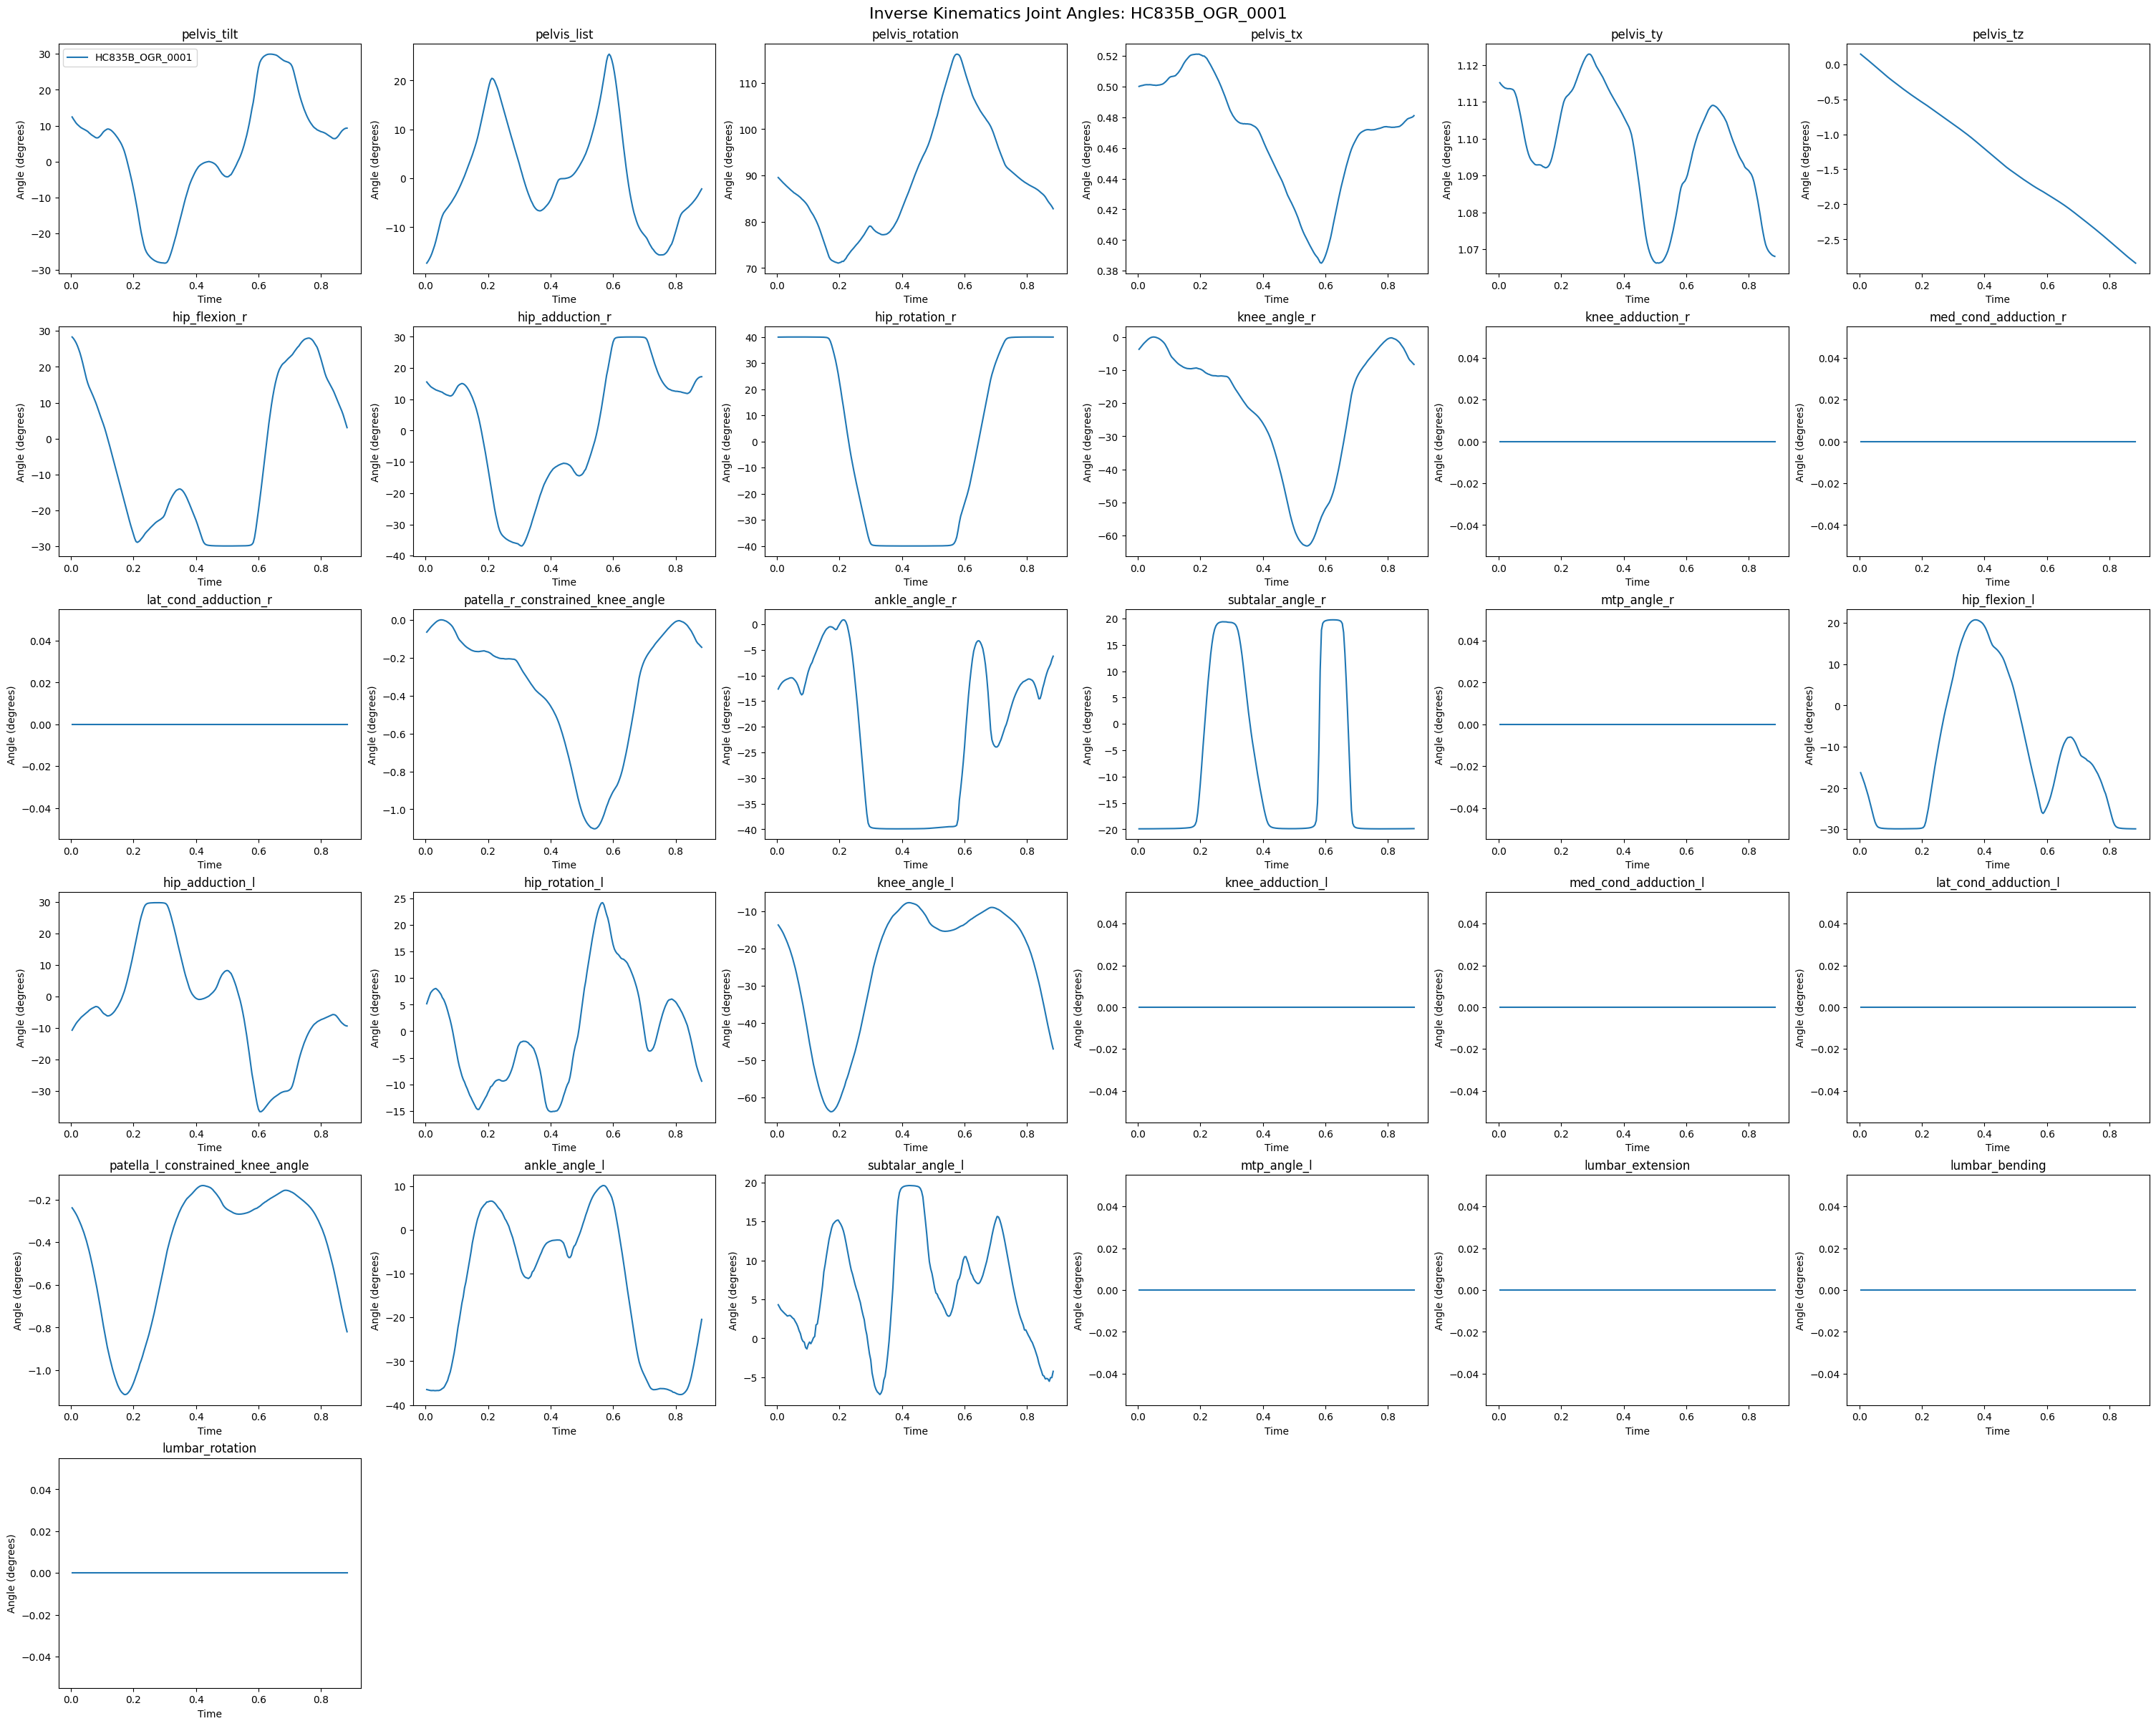

In [4]:
analysis.update_trial_attribute('replace', 'True')
analysis.run_ik()

## Run Inverse Dynamics

In [ ]:
analysis.run_id()

## Run Muscle Analysis

In [ ]:
analysis.update_trial_attribute('replace', 'True')
analysis.run_ma()

## Run Static Optimisation

In [ ]:
analysis.update_trial_attribute('replace', 'True')
# model_path = os.path.join(utils.MODELS_DIR, subject, session, 'scaled_opt_N10_increased_3.00.osim')
# analysis.update_model(model_path)
analysis.load_settings(analysis.settingsXML)
analysis.run_so()

## Run Joint Reaction Analysis (with SO results)

In [ ]:
analysis.update_trial_attribute('replace', 'True')
analysis.run_jra()

## emg normalise / scale / plot

In [ ]:
analysis.run_emg_normalise()

In [ ]:
analysis.scale_emg(scale_factor=0.70)

In [ ]:
analysis.plot_emg()

## Create ceinms setup files

In [ ]:
analysis.create_ceinms_input_data()

In [ ]:
analysis.update_trial_attribute('replace', 'False')

analysis.create_ceinms_model()

analysis.create_ceinms_calibration_cfg(calibration_trial_names=['Walking_02', 'Squat_BW_01'])

analysis.create_ceinms_calibration_setup()


In [ ]:
analysis.update_trial_attribute('replace', 'True')
analysis.create_excitation_generator()

## ceinms calibration

In [ ]:
analysis.run_ceinms_calibration()


## ceinms exe setups

In [ ]:
# print ceinms settings
print('CEIMS Settings:')
print(f'alpha: {analysis.alpha}')
print(f'beta: {analysis.beta}')
print(f'gamma: {analysis.gamma}')
print(f'ceinms_exe_dir: {analysis.ceinms_exe_dir}')

In [ ]:
analysis.create_ceinms_exe_cfg()

analysis.create_ceinms_exe_setup()

In [ ]:
analysis.create_ceinms_cfg_from_excitation_generator()

## run ceinms exe

In [ ]:
analysis.run_ceinms_exe()


In [ ]:
analysis.plot_ceinms_vs_so_muscle_moments()

## ceinms optimise

In [ ]:
analysis.create_ceinms_optimise_setup()

In [ ]:
analysis.run_ceinms_optimise()

In [ ]:
ceinms.plot_optimisation_results(analysis.ceinms_optimisation_dir)

ceinms_excitations = os.path.join(analysis.ceinms_optimisation_dir, 'AdjustedEmgs.sto')
ceinms_torques = os.path.join(analysis.ceinms_optimisation_dir, 'Torques.sto')

ceinms.plot_experimental_vs_ceinms(emgFile=analysis.emg_normalised, ceinmsExcitationsFile=ceinms_excitations, excitationGeneratorFile=analysis.ceinms_excitation_generator, externalMomentsFile=analysis.id,ceinmsTorquesFile=ceinms_torques)

## JRA ceinms 

In [ ]:
# Use if need to replace model for CEINMS execution 
if analysis.model_name.__contains__('_increased_3.00'):
    new_model_name = analysis.model_name.replace('_increased_3.00.osim', '.osim')
    analysis.update_model(new_model_name)

In [ ]:
analysis.update_trial_attribute('replace', 'True')
analysis.run_jra_ceinms()

## JRA 

In [ ]:
if not analysis.model_name.__contains__('_increased_3.00'):
    new_model_name = analysis.model_name.replace('.osim', '_increased_3.00.osim')
    analysis.update_model(new_model_name)

print(f'model to use: {os.path.abspath(analysis.model_dir)}')

In [ ]:
analysis.update_trial_attribute('replace', 'True')
analysis.run_jra()


## Compare SO and CEINMS (activations, force, emg)

In [ ]:
so_forces = utils.load_any_data_file(analysis.jra_forces)
ceinms_forces = utils.load_any_data_file(analysis.jra_forces_ceinms)

so_activations = utils.load_any_data_file(os.path.join(analysis.path, analysis.so_activations))
ceinms_activations = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra_forces_ceinms.replace('MuscleForces.sto', 'Activations.sto')))

so_lengths = utils.load_any_data_file(os.path.join(analysis.path, analysis.ma, '_MuscleAnalysis_NormalizedFiberLength.sto'))
ceinms_lengths = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra_forces_ceinms.replace('MuscleForces.sto', 'NormFibreLengths.sto')))

emg = utils.load_any_data_file(os.path.join(analysis.path, analysis.ceinms_excitations))
emg = emg[emg['time'].isin(so_activations['time'])]


excitation_mapping = ET.parse(os.path.join(analysis.path, analysis.ceinms_excitation_generator)).getroot()

labels = {'SO':'SO', 'CEINMS':'CEINMS'}
lineStyles = {'SO':'-', 'CEINMS':'--'}
colors = {'SO':'tab:blue', 'CEINMS':'tab:orange'}

muscleGroups = {'R Gluteus maximus':['glmax1_r','glmax2_r','glmax3_r'],
                        'R Gluteus medius':['glmed1_r','glmed2_r','glmed3_r'],
                        'R Gluteus minimus':['glmin1_r','glmin2_r','glmin3_r'], 
                        'R Adductor Magnus': ['addmagDist_r','addmagIsch_r','addmagMid_r','addmagProx_r'],
                        'R Biceps Femoris': ['bflh_r','bfsh_r'],
                        'R Semimembranosus': ['semimem_r'],
                        'R Semitendinosus': ['semiten_r'],
                        'R Rectus Femoris': ['recfem_r'],
                        'R Vasti':['vasint_r','vaslat_r','vasmed_r'],
                        'R Triceps Surae': ['soleus_r','gaslat_r','gasmed_r'],
                        'L Gluteus maximus':['glmax1_l','glmax2_l','glmax3_l'],
                        'L Gluteus medius':['glmed1_l','glmed2_l','glmed3_l'],
                        'L Gluteus minimus':['glmin1_l','glmin2_l','glmin3_l'], 
                        'L Adductor Magnus': ['addmagDist_l','addmagIsch_l','addmagMid_l','addmagProx_l'],
                        'L Biceps Femoris': ['bflh_l','bfsh_l'],
                        'L Semimembranosus': ['semimem_l'],
                        'L Semitendinosus': ['semiten_l'],
                        'L Rectus Femoris': ['recfem_l'],
                        'L Vasti':['vasint_l','vaslat_l','vasmed_l'],
                        'L Triceps Surae': ['soleus_l','gaslat_l','gasmed_l'],
                        }

def get_emg_signals_for_muscle_groups(analysis: utils.Analyse, muscles: list):

    signals = []
    for muscle in muscles:
        signal = analysis.get_muscle_excitation_mapping(muscle)
        
        if signal:
            signals.append(signal)

    # Flatten the list and delete duplicate signals after processing all muscles
    if signals:
        # Flatten list of lists to a single list
        flattened_signals = [item for sublist in signals for item in (sublist if isinstance(sublist, list) else [sublist])]
        # Remove duplicates
        signals = list(set(flattened_signals))
    
    return signals

n_cols = 5
n_rows = len(muscleGroups) // n_cols + (len(muscleGroups) % n_cols > 0)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Muscle Force Comparison SO vs CEINMS', fontsize=16)

for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    row = count // n_cols
    col_name = count % n_cols
    ax = ax.flatten()
    
    # SO forces and activations
    sum_forces = so_forces[muscles].sum(axis=1)
    ax[count].plot(so_forces['time'], sum_forces, label=labels['SO'], color=colors['SO'])

    # CEINMS forces and activations
    sum_forces = ceinms_forces[muscles].sum(axis=1)
    ax[count].plot(ceinms_forces['time'], sum_forces, label=labels['CEINMS'], color=colors['CEINMS'], linestyle=lineStyles['CEINMS'])
    ax[count].set_title(f'{muscleGroup}')

    if count == 0:
        ax[count].legend(loc='upper right')


save_path = os.path.join(analysis.path, 'muscle_force_comparison.png')
fig.savefig(save_path)
print(f'Saved figure to {save_path}')


# Activations
n_cols = 5
n_rows = len(muscleGroups) // n_cols + (len(muscleGroups) % n_cols > 0)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Muscle Activations Comparison SO vs CEINMS', fontsize=16)

for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    row = count // n_cols
    col_name = count % n_cols
    ax = ax.flatten()

    emg_labels = get_emg_signals_for_muscle_groups(analysis, muscles)
    
    # SO ctivations
    ax1 = ax[count]
    
    ax1.plot(so_activations['time'], so_activations[muscles].mean(axis=1), color=colors['SO'], alpha=0.3, linewidth=2, label='SO Activations', linestyle=lineStyles['SO'])

    # CEINMS activations
    ax1.plot(ceinms_activations['time'], ceinms_activations[muscles].mean(axis=1), color=colors['CEINMS'], alpha=0.3, linewidth=2, label='CEINMS Activations', linestyle=lineStyles['CEINMS'])
    ax1.set_title(f'{muscleGroup}')
    
    # EMG in a grey path for reference
    if len(emg_labels) > 0:
        ax1.fill_between(emg['time'], 0, emg[emg_labels].mean(axis=1), color='gray', alpha=0.2, label='EMG')
        ax1.plot(emg['time'], emg[emg_labels].mean(axis=1), color='gray', linewidth=2)

        # calculare r2 and RMSE between SO and CEINMS activations and EMG
        rmse_so = utils.rmse(so_activations[muscles].mean(axis=1), emg[emg_labels].mean(axis=1))
        r2_so = utils.rsquared(so_activations[muscles].mean(axis=1), emg[emg_labels].mean(axis=1))
        rmse_ceinms = utils.rmse(ceinms_activations[muscles].mean(axis=1), emg[emg_labels].mean(axis=1))
        r2_ceinms = utils.rsquared(ceinms_activations[muscles].mean(axis=1), emg[emg_labels].mean(axis=1))

        # Add text box with RMSE and R2 values
        if len(emg_labels) > 0:
            textstr = f'SO: RMSE={rmse_so:.3f}, R²={r2_so:.3f}\nCEINMS: RMSE={rmse_ceinms:.3f}, R²={r2_ceinms:.3f}'
            ax1.text(0.95, 0.95, textstr, transform=ax1.transAxes, fontsize=8,
                    verticalalignment='top', horizontalalignment='right',
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    if count == 0:
        ax1.legend(loc='upper left', bbox_to_anchor=(0.5, 1.5), framealpha=0.9)

save_path = os.path.join(analysis.path, 'muscle_activation_comparison.png')
fig.savefig(save_path)
print(f'Saved figure to {save_path}')


# Fiber Lengths
n_cols = 5
n_rows = len(muscleGroups) // n_cols + (len(muscleGroups) % n_cols > 0)
fig, ax = plt.subplots(n_rows, n_cols, figsize=(20, 5*n_rows))
fig.suptitle('Muscle Fiber Length Comparison SO vs CEINMS', fontsize=16)


for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    row = count // n_cols
    col_name = count % n_cols
    ax = ax.flatten()
    
    # SO fiber lengths
    mean_lengths = so_lengths[muscles].mean(axis=1)
    ax[count].plot(so_lengths['time'], mean_lengths, label=labels['SO'], color=colors['SO'])

    # CEINMS fiber lengths
    mean_lengths = ceinms_lengths[muscles].mean(axis=1)
    ax[count].plot(ceinms_lengths['time'], mean_lengths, label=labels['CEINMS'], color=colors['CEINMS'], linestyle=lineStyles['CEINMS'])
    ax[count].set_title(f'{muscleGroup}')

    if count == 0:
        ax[count].legend(loc='upper right')

save_path = os.path.join(analysis.path, 'muscle_fiber_length_comparison.png')
fig.savefig(save_path)
print(f'Saved figure to {save_path}')

In [ ]:
# r2_so = utils.rsquared(so_activations[muscles].mean(axis=1), emg[emg_labels].mean(axis=1))
emg[emg_labels].mean(axis=1)
# so_activations[muscles].mean(axis=1)

## Compare muscle moments 

In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go

ik_columns = ['hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r', 'knee_adduction_r', 'ankle_angle_r']
id_columns = [f'{dof}_moment' for dof in ik_columns]

id = utils.load_any_data_file(os.path.join(analysis.path, analysis.id))
so_forces = utils.load_any_data_file(os.path.join(analysis.path, analysis.so_forces))
ceinms_forces = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra_forces_ceinms))

fig, ax = plt.subplots(nrows=len(ik_columns), ncols=2, figsize=(28, 16))
fontsize = 25

fig_int = make_subplots(rows=len(ik_columns), cols=2, shared_xaxes=True,
                        subplot_titles=[f"{dof} - SO" if i % 2 == 0 else f"{dof} - CEINMS"
                                        for dof in ik_columns for i in range(2)])

for count, dof in enumerate(ik_columns):
    ma = utils.load_any_data_file(os.path.join(analysis.path, analysis.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto'))

    muscle_list = [col for col in so_forces.columns if col != 'time']
    muscles = openSim.find_non_zero_mom_arm_muscles(ma, muscle_list)
    print(f"Non-zero moment arm muscles for {dof}: {muscles}")

    colors = plt.cm.tab20(np.linspace(0, 1, max(len(muscles), 1)))

    if count == 0:
        ax[count, 0].set_title('SO', fontsize=fontsize)
        ax[count, 1].set_title('CEINMS', fontsize=fontsize)

    # Plot ID (static)
    ax[count, 0].plot(id['time'], id[f'{dof}_moment'], label='ID', color='blue')
    ax[count, 0].set_ylabel(f'{dof} (Nm)', fontsize=fontsize)
    ax[count, 0].tick_params(labelsize=fontsize)

    ax[count, 1].plot(id['time'], id[f'{dof}_moment'], label='ID', color='blue')
    ax[count, 1].tick_params(labelsize=fontsize)

    
    # Plot muscle moments SO (static)
    for i, m in enumerate(muscles):
        ax[count, 0].plot(so_forces['time'], so_forces[m] * ma[m],
                          label=m, color=colors[i], linestyle='--')

    sum_moments_so = so_forces[muscles].mul(ma[muscles], axis=0).sum(axis=1)
    ax[count, 0].fill_between(so_forces['time'], 0, sum_moments_so, color='grey', alpha=0.2, label='Sum')

    # Plot muscle moments CEINMS (static)
    for i, m in enumerate(muscles):
        ax[count, 1].plot(ceinms_forces['time'], ceinms_forces[m] * ma[m],
                          label=m, color=colors[i], linestyle='--')
    
    sum_moments_ce = ceinms_forces[muscles].mul(ma[muscles], axis=0).sum(axis=1)
    ax[count, 1].fill_between(ceinms_forces['time'], 0, sum_moments_ce, color='grey', alpha=0.2, label='Sum')

    # add RMSE and R2 values between ID and SO, and ID and CEINMS
    rmse_so = utils.rmse(id[f'{dof}_moment'], sum_moments_so)
    r2_so = utils.rsquared(id[f'{dof}_moment'], sum_moments_so)
    rmse_ce = utils.rmse(id[f'{dof}_moment'], sum_moments_ce)
    r2_ce = utils.rsquared(id[f'{dof}_moment'], sum_moments_ce)
    textstr_so = f'RMSE={rmse_so:.2f} Nm\nR²={r2_so:.3f}'
    textstr_ce = f'RMSE={rmse_ce:.2f} Nm\nR²={r2_ce:.3f}'
    ax[count, 0].text(0.95, 0.95, textstr_so, transform=ax[count, 0].transAxes, fontsize=fontsize,
                      verticalalignment='top', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax[count, 1].text(0.95, 0.95, textstr_ce, transform=ax[count, 1].transAxes, fontsize=fontsize,
                      verticalalignment='top', horizontalalignment='right',
                      bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))    


fig.tight_layout()
save_path = os.path.join(analysis.path, 'muscle_moments.png')
fig.savefig(save_path)
print(f"Muscle moments comparison plot saved: {save_path}")



In [ ]:
utils.convert_to_interactive_fig(fig, html_path=os.path.join(analysis.path, 'muscle_moments_interactive.html'))

## Compare JRA SO and CEINMS

In [ ]:
jra_dict = {'hip': ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz'],
            'knee': ['knee_r_on_tibia_r_in_tibia_r_fx', 'knee_r_on_tibia_r_in_tibia_r_fy', 'knee_r_on_tibia_r_in_tibia_r_fz'],
            'ankle': ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']}


jra_dict = {'hip': ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz'],
            'knee': ['med_cond_joint_r_on_med_cond_r_in_med_cond_r_fx', 'med_cond_joint_r_on_med_cond_r_in_med_cond_r_fy', 'med_cond_joint_r_on_med_cond_r_in_med_cond_r_fz'],
            'ankle': ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']}

In [ ]:
jra_Scaled_so = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra))
jra_Scaled_ceinms = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra_ceinms))

fig, ax = plt.subplots(3,   4, figsize=(15, 8))

labels = ['SO', 'CEINMS']
lineStyles = ['-', '--']
count = -1
for df in [jra_Scaled_so, jra_Scaled_ceinms]:
    count += 1
    
    # plot Hip first row    
    x = df[jra_dict['hip'][0]]
    y = df[jra_dict['hip'][1]]
    z = df[jra_dict['hip'][2]]
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[0, 0].plot(df['time'], x, label=labels[count], linestyle=lineStyles[count])
    ax[0, 1].plot(df['time'], y, label=labels[count], linestyle=lineStyles[count])
    ax[0, 2].plot(df['time'], z, label=labels[count], linestyle=lineStyles[count])
    ax[0, 3].plot(df['time'], sum, label=labels[count], linestyle=lineStyles[count])
    
    ax[0, 0].set_ylabel(' Hip Force (N)')
    ax[0, 0].set_title('X (+ anterior, - posterior)')
    ax[0, 1].set_title('Y (+ medial, - lateral)')
    ax[0, 2].set_title('Z (+ superior, - inferior)')
    ax[0, 3].set_title('Resultant Force Magnitude')

    # plot Knee second row
    x = df[jra_dict['knee'][0]]
    y = df[jra_dict['knee'][1]]
    z = df[jra_dict['knee'][2]]

    sum = np.linalg.norm([x,y,z], axis=0)
    ax[1, 0].plot(df['time'], x, label=labels[count], linestyle=lineStyles[count])
    ax[1, 1].plot(df['time'], y, label=labels[count], linestyle=lineStyles[count])
    ax[1, 2].plot(df['time'], z, label=labels[count], linestyle=lineStyles[count])
    ax[1, 3].plot(df['time'], sum, label=labels[count], linestyle=lineStyles[count])

    ax[1, 0].set_ylabel(' Knee Force (N)')
    
    
    # plot Ankle last row
    x = df[jra_dict['ankle'][0]]
    y = df[jra_dict['ankle'][1]]
    z = df[jra_dict['ankle'][2]]
    sum = np.linalg.norm([x,y,z], axis=0)
    ax[2, 0].plot(df['time'], x, label=labels[count], linestyle=lineStyles[count])
    ax[2, 1].plot(df['time'], y, label=labels[count], linestyle=lineStyles[count])
    ax[2, 2].plot(df['time'], z, label=labels[count], linestyle=lineStyles[count])
    ax[2, 3].plot(df['time'], sum, label=labels[count], linestyle=lineStyles[count])

    ax[2, 0].set_ylabel(' Ankle Force (N)')
    
        

ax[0, 0].legend()
plt.tight_layout()
save_path = os.path.join(analysis.path, f'jra_so_vs_ceinms.png')
plt.savefig(save_path)
print(f"JRA comparison plot saved: {save_path}")
    



## push to git (trial)

In [ ]:
analysis.push_trial_results_to_git()

## push to git (subject)

In [ ]:
analysis.push_subject_results_to_git()

# Troubleshoot

In [ ]:
analysis.load_settings(analysis.settingsXML)
osim_modelPath = analysis.model_dir
ik_output = os.path.join(analysis.path, analysis.ik)
grf_xml = os.path.join(analysis.path, analysis.setup_grf)
setup_jra_xml = os.path.join(analysis.path, analysis.setup_jra)
actuators_xml = None
muscle_force_path = os.path.join(analysis.path, analysis.jra_forces_ceinms).replace('MuscleForces', 'MuscleForces_updated')
saveFileName = os.path.join(analysis.path, "JRA_results.sto")

openSim.run_jra(osim_modelPath=osim_modelPath, 
                ik_output=ik_output, 
                grf_xml=grf_xml, 
                setup_xml=setup_jra_xml, 
                actuators=actuators_xml, 
                muscle_force_path=muscle_force_path, 
                saveFileName=saveFileName)

In [ ]:
setupXML_path = r'C:\Git\powerlifing_model\simulations\Athlete_03\25_03_31\Walking_02\ceinms_setup.xml'
ceinms.executable(setupXML_path)

## Compare multiple files

In [ ]:
filepath1 = os.path.join(analysis.path, analysis.jra)
filepath2 = os.path.join(analysis.path, analysis.jra_ceinms)
filepath3 = os.path.join(analysis.path, analysis.jra_ceinms).replace('MuscleForces', 'MuscleForces_updated')

files = {'so': utils.load_any_data_file(filepath1),
         'ceinms': utils.load_any_data_file(filepath2),
         'ceinms_with_SO_updated': utils.load_any_data_file(filepath3)}

results_dir = os.path.join(utils.RESULTS_DIR, 'compare')
os.makedirs(results_dir, exist_ok=True)

common_columns = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz', 'walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz', 'ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

nrows, ncols = utils.calculate_nRows_nCols(len(common_columns))

fig, ax = plt.subplots(nrows=nrows, ncols=ncols, figsize=(10, 6*nrows))

for file_key, data in files.items():
    print(f"{file_key} columns: {data.columns}")

    for idx, column in enumerate(common_columns):
        row = idx // ncols
        col_name = idx % ncols
        ax[row, col_name].plot(data['time'], data[column], label=file_key)
        ax[row, col_name].set_title(column)
        ax[row, col_name].set_xlabel('Time (s)')
        ax[row, col_name].set_ylabel('Value')
        ax[row, col_name].legend()
# plt.tight_layout()
save_path = os.path.join(results_dir, 'comparison_plot.png')

In [ ]:
# compare columns SO vs CEINMS forces
ceinms_forces = utils.load_any_data_file(os.path.join(analysis.path, analysis.jra_forces_ceinms))
so_forces = utils.load_any_data_file(os.path.join(analysis.path, analysis.so_forces))

for column in so_forces.columns:
    if not column in ceinms_forces.columns:
        print(f"Column {column} not found in CEINMS forces.")
        
        # add column to ceinms_forces with the same valuse as SO
        ceinms_forces[column] = so_forces[column]

utils.write_sto_file(ceinms_forces, os.path.join(analysis.path, analysis.jra_forces_ceinms).replace('.sto', '_updated.sto'))
print(f"Saved updated CEINMS forces to {os.path.join(analysis.path, analysis.jra_forces_ceinms).replace('.sto', '_updated.sto')}")
        

# WCB 2026

## Load data and assign plotting settings

In [ ]:

trialName = 'Walking_02'
walking_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', trialName))
walking_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', trialName))

squat_trial = 'Squat_bw_01'
squat_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', squat_trial))
squat_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', squat_trial))

weighted_squat_tiral = 'Squat_35kg_01'
weighted_squat_scaled = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', weighted_squat_tiral))
weighted_squat_MRI = utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_MRI_BG', '25_03_31', weighted_squat_tiral))

colors = {'scaled': 'blue',
          'MRI_BG': 'orange'}

font_size = 20

results_dir = os.path.join(utils.RESULTS_DIR, 'wcb_2026')
os.makedirs(results_dir, exist_ok=True)

Muscle_GroupsR = {'Hip': ['addbrev_r', 'addlong_r', 'addmagDist_r', 'addmagIsch_r', 'addmagMid_r', 'addmagProx_r', 'bflh_r', 'gaslat_r', 'gasmed_r', 'glmax1_r', 'glmax2_r', 'glmax3_r', 'glmed1_r', 'glmed2_r', 'glmed3_r', 'glmin1_r', 'glmin2_r', 'glmin3_r', 'grac_r', 'iliacus_r', 'piri_r', 'psoas_r', 'recfem_r', 'sart_r', 'semimem_r', 'semiten_r', 'tfl_r'],
                    'Knee': ['bflh_r', 'bfsh_r', 'gaslat_r', 'gasmed_r', 'grac_r', 'recfem_r', 'sart_r', 'semimem_r', 'semiten_r', 'vasint_r', 'vaslat_r', 'vasmed_r'],
                    'Ankle': ['edl_r', 'ehl_r', 'fdl_r', 'fhl_r', 'gaslat_r', 'gasmed_r', 'perbrev_r', 'perlong_r', 'soleus_r', 'tibant_r', 'tibpost_r']}

Muscle_GroupsL = {'Hip': [muscle.replace('_r', '_l') for muscle in Muscle_GroupsR['Hip']],
                    'Knee': [muscle.replace('_r', '_l') for muscle in Muscle_GroupsR['Knee']],
                    'Ankle': [muscle.replace('_r', '_l') for muscle in Muscle_GroupsR['Ankle']]}

# Define trials
trials = [
    ('Walking', walking_scaled, walking_MRI),
    ('Squat BW', squat_scaled, squat_MRI),
    ('Squat 35kg', weighted_squat_scaled, weighted_squat_MRI)
]



## main figure

In [ ]:
fig, ax = plt.subplots(nrows=3, ncols=3, figsize=(20, 8))


# Define joint columns
hip = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
knee = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
ankle = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

joints = [
    ('Hip', hip),
    ('Knee', knee),
    ('Ankle', ankle)
]

def sum3d(df, columns):
    x = df[columns[0]]
    y = df[columns[1]]
    z = df[columns[2]]
    sum_val = np.sqrt(x**2 + y**2 + z**2)
    return sum_val

for trial_idx, (trial_name, scaled_trial, mri_trial) in enumerate(trials):
    # Load data
    scaled_so = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra))
    mri_so = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra))
    scaled_ceinms = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_ceinms))
    mri_ceinms = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_ceinms))
    
    for joint_idx, (joint_name, joint_cols) in enumerate(joints):
        # Calculate 3D sum for each condition
        scaled_so_jrf = sum3d(scaled_so, joint_cols)
        mri_so_jrf = sum3d(mri_so, joint_cols)
        scaled_ceinms_jrf = sum3d(scaled_ceinms, joint_cols)
        mri_ceinms_jrf = sum3d(mri_ceinms, joint_cols)
        
        # Plot
        ax[trial_idx, joint_idx].plot(scaled_so['time'], scaled_so_jrf, label='Scaled Model | Static Optimization', 
                           color=colors['scaled'], linestyle='-', linewidth=2)
        ax[trial_idx, joint_idx].plot(mri_so['time'], mri_so_jrf, label='MRI_BG Model | Static Optimization', 
                                       color=colors['MRI_BG'], linestyle='-', linewidth=2)
        ax[trial_idx, joint_idx].plot(scaled_ceinms['time'], scaled_ceinms_jrf, label='Scaled Model | EMG informed (8 muscles)', 
                                       color=colors['scaled'], linestyle='--', linewidth=2)
        ax[trial_idx, joint_idx].plot(mri_ceinms['time'], mri_ceinms_jrf, label='MRI_BG Model | EMG informed (8 muscles)', 
                                       color=colors['MRI_BG'], linestyle='--', linewidth=2)
        
        # Calculate mean differences as percentage of range
        range_scaled_so = scaled_so_jrf.max() - scaled_so_jrf.min()
        
        diff_so_scaled_vs_mri = (scaled_so_jrf - mri_so_jrf).mean()
        diff_so_scaled_vs_ceinms_scaled = (scaled_so_jrf - scaled_ceinms_jrf).mean()
        diff_ceinms_scaled_vs_mri = (scaled_ceinms_jrf - mri_ceinms_jrf).mean()
        
        std_so_scaled_vs_mri = (scaled_so_jrf - mri_so_jrf).std()
        std_so_scaled_vs_ceinms_scaled = (scaled_so_jrf - scaled_ceinms_jrf).std()
        std_ceinms_scaled_vs_mri = (scaled_ceinms_jrf - mri_ceinms_jrf).std()
        
        # Convert to percentage
        if range_scaled_so != 0:
            diff_so_scaled_vs_mri_pct = (diff_so_scaled_vs_mri / range_scaled_so) * 100
            diff_so_scaled_vs_ceinms_scaled_pct = (diff_so_scaled_vs_ceinms_scaled / range_scaled_so) * 100
            diff_ceinms_scaled_vs_mri_pct = (diff_ceinms_scaled_vs_mri / range_scaled_so) * 100
            
            std_so_scaled_vs_mri_pct = (std_so_scaled_vs_mri / range_scaled_so) * 100
            std_so_scaled_vs_ceinms_scaled_pct = (std_so_scaled_vs_ceinms_scaled / range_scaled_so) * 100
            std_ceinms_scaled_vs_mri_pct = (std_ceinms_scaled_vs_mri / range_scaled_so) * 100
        else:
            diff_so_scaled_vs_mri_pct = 0
            diff_so_scaled_vs_ceinms_scaled_pct = 0
            diff_ceinms_scaled_vs_mri_pct = 0
            std_so_scaled_vs_mri_pct = 0
            std_so_scaled_vs_ceinms_scaled_pct = 0
            std_ceinms_scaled_vs_mri_pct = 0
        
        # Add text with statistics
        text_str = f'SO_scaled vs SO_MRI: {diff_so_scaled_vs_mri_pct:.1f}±{std_so_scaled_vs_mri_pct:.1f}%\n'
        text_str += f'SO_scaled vs CEINMS_scaled: {diff_so_scaled_vs_ceinms_scaled_pct:.1f}±{std_so_scaled_vs_ceinms_scaled_pct:.1f}%\n'
        text_str += f'CEINMS_scaled vs MRI_CEINMS: {diff_ceinms_scaled_vs_mri_pct:.1f}±{std_ceinms_scaled_vs_mri_pct:.1f}%'
        
        ax[trial_idx, joint_idx].text(0.02, 0.98, text_str, transform=ax[trial_idx, joint_idx].transAxes,
                                       fontsize=9, verticalalignment='top', 
                                       bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
        
        ax[trial_idx, joint_idx].set_title(f'{trial_name} - {joint_name} JCF', fontsize=12)
        ax[trial_idx, joint_idx].set_ylabel('Joint Contact Force (N)', fontsize=10)
        
        if trial_idx == 2:
            ax[trial_idx, joint_idx].set_xlabel('Time (s)', fontsize=10)
        
        if trial_idx == 0 and joint_idx == 0:
            ax[trial_idx, joint_idx].legend(fontsize=10, loc='upper right')

plt.tight_layout()
save_path = os.path.join(results_dir, f'jrf_comparison_4_lines_with_stats.png')
plt.savefig(save_path, dpi=300)
print(f"JRF comparison (4 lines with statistics) saved: {save_path}")

In [ ]:



results_data = []
fig, ax = plt.subplots(nrows=3, ncols=len(Muscle_GroupsR), figsize=(10, 8))
fig.suptitle('Muscle Forces Differences Across Trials and Muscle Groups', fontsize=12)
for trial_idx, (trial_name, scaled_trial, mri_trial) in enumerate(trials):
    # Load data
    scaled_so = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.so_forces))
    mri_so = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.so_forces))
    scaled_ceinms = utils.load_any_data_file(os.path.join(scaled_trial.path, scaled_trial.jra_forces_ceinms))
    mri_ceinms = utils.load_any_data_file(os.path.join(mri_trial.path, mri_trial.jra_forces_ceinms))
    
    for idx, (group_name, muscles_r) in enumerate(Muscle_GroupsR.items()):
        muscles_l = Muscle_GroupsL[group_name]

        if trial_name.__contains__('Walking'):
            # use only the walking leg
            scaled_so_avg = scaled_so[muscles_r].sum(axis=1)
            mri_so_avg = mri_so[muscles_r].sum(axis=1)
            scaled_ceinms_avg = scaled_ceinms[muscles_r].sum(axis=1)
            mri_ceinms_avg = mri_ceinms[muscles_r].sum(axis=1)
        else:
            # Calculate bilateral average (sum of both legs divided by 2)
            scaled_so_avg = (scaled_so[muscles_r].sum(axis=1) + scaled_so[muscles_l].sum(axis=1)) / 2
            mri_so_avg = (mri_so[muscles_r].sum(axis=1) + mri_so[muscles_l].sum(axis=1)) / 2
            scaled_ceinms_avg = (scaled_ceinms[muscles_r].sum(axis=1) + scaled_ceinms[muscles_l].sum(axis=1)) / 2
            mri_ceinms_avg = (mri_ceinms[muscles_r].sum(axis=1) + mri_ceinms[muscles_l].sum(axis=1)) / 2
        
        
        # Calculate mean differences and std
        diff_so_scaled_vs_mri = (scaled_so_avg.mean() - mri_so_avg.mean())
        diff_so_scaled_vs_ceinms_scaled = (scaled_so_avg.mean() - scaled_ceinms_avg.mean())
        diff_ceinms_scaled_vs_mri = (scaled_ceinms_avg.mean() - mri_ceinms_avg.mean())
        diff_so_scaled_vs_ceinms_mri = (scaled_so_avg.mean() - mri_ceinms_avg.mean())   

        std_diff_so_scaled_vs_mri = (scaled_so_avg - mri_so_avg).std()
        std_diff_so_scaled_vs_ceinms_scaled = (scaled_so_avg - scaled_ceinms_avg).std()
        std_diff_ceinms_scaled_vs_mri = (scaled_ceinms_avg - mri_ceinms_avg).std()
        std_diff_so_scaled_vs_ceinms_mri = (scaled_so_avg - mri_ceinms_avg).std()

        # Calculate range for percentage
        range_so_scaled = scaled_so_avg.max() - scaled_so_avg.min()

        # Convert to percentage of range
        diff_so_scaled_vs_mri_pct = (diff_so_scaled_vs_mri / range_so_scaled) * 100
        diff_so_scaled_vs_ceinms_scaled_pct = (diff_so_scaled_vs_ceinms_scaled / range_so_scaled) * 100
        diff_ceinms_scaled_vs_mri_pct = (diff_ceinms_scaled_vs_mri / range_so_scaled) * 100
        diff_so_scaled_vs_ceinms_mri_pct = (diff_so_scaled_vs_ceinms_mri / range_so_scaled) * 100
        
        std_diff_so_scaled_vs_mri_pct = (std_diff_so_scaled_vs_mri / range_so_scaled) * 100
        std_diff_so_scaled_vs_ceinms_scaled_pct = (std_diff_so_scaled_vs_ceinms_scaled / range_so_scaled) * 100
        std_diff_ceinms_scaled_vs_mri_pct = (std_diff_ceinms_scaled_vs_mri / range_so_scaled) * 100
        std_diff_so_scaled_vs_ceinms_mri_pct = (std_diff_so_scaled_vs_ceinms_mri / range_so_scaled) * 100

        # Store results
        results_data.append({
            'Trial': trial_name,
            'Muscle_Group': group_name,
            'Mean_Diff_SO_scaled_vs_SO_MRI': diff_so_scaled_vs_mri_pct,
            'Std_Diff_SO_scaled_vs_SO_MRI': std_diff_so_scaled_vs_mri_pct,
            'Mean_Diff_SO_scaled_vs_CEINMS_scaled': diff_so_scaled_vs_ceinms_scaled_pct,
            'Std_Diff_SO_scaled_vs_CEINMS_scaled': std_diff_so_scaled_vs_ceinms_scaled_pct,
            'Mean_Diff_CEINMS_scaled_vs_MRI_CEINMS': diff_ceinms_scaled_vs_mri_pct,
            'Std_Diff_CEINMS_scaled_vs_MRI_CEINMS': std_diff_ceinms_scaled_vs_mri_pct,
            'Mean_Diff_SO_scaled_vs_MRI_CEINMS': diff_so_scaled_vs_ceinms_mri_pct,
            'Std_Diff_SO_scaled_vs_MRI_CEINMS': std_diff_so_scaled_vs_ceinms_mri_pct
        })
        
        # Create bar plot
        x_pos = [0, 1, 2, 3]
        differences = [diff_so_scaled_vs_mri_pct, diff_so_scaled_vs_ceinms_scaled_pct, diff_ceinms_scaled_vs_mri_pct, diff_so_scaled_vs_ceinms_mri_pct]
        labels = ['SO_scaled vs\nSO_MRI', 'SO_scaled vs\nCEINMS_scaled', 'CEINMS_scaled vs\nMRI_CEINMS', 'SO_scaled vs\nMRI_CEINMS']
        
        bars = ax[trial_idx, idx].bar(x_pos, differences, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
        
        # Add error bars with standard deviation
        std_errors = [std_diff_so_scaled_vs_mri_pct, std_diff_so_scaled_vs_ceinms_scaled_pct, std_diff_ceinms_scaled_vs_mri_pct, std_diff_so_scaled_vs_ceinms_mri_pct] 
        ax[trial_idx, idx].errorbar(x_pos, differences, yerr=std_errors, fmt='none', ecolor='black', capsize=3, capthick=1)
        
        # Add horizontal line at y=0
        ax[trial_idx, idx].axhline(y=0, color='black', linestyle='-', linewidth=0.5)
        
        ax[trial_idx, idx].set_xticks(x_pos)
        ax[trial_idx, idx].set_xticklabels(labels, fontsize=8, rotation=0)
        ax[trial_idx, idx].set_title(f'{trial_name} - {group_name}', fontsize=10)
        ax[trial_idx, idx].set_ylabel('Mean Difference (%)', fontsize=9)
        
        # if last row, set x ticks otherwise remove them
        if trial_idx == 2:
            ax[trial_idx, idx].set_xticklabels(labels, fontsize=8, rotation=45)
        else:
            ax[trial_idx, idx].set_xticklabels([])

plt.tight_layout()


save_path = os.path.join(results_dir, f'muscle_forces_differences_3groups_bar_plots.png')
plt.savefig(save_path, dpi=300)
print(f"Muscle forces differences bar plots saved: {save_path}")

# Create DataFrame and save to CSV
results_df = pd.DataFrame(results_data)
csv_path = os.path.join(results_dir, 'muscle_forces_differences_3groups_statistics.csv')
results_df.to_csv(csv_path, index=False)
print(f"Statistics saved to: {csv_path}")

## Combine figures

In [ ]:
from PIL import Image

figure1 = os.path.join(results_dir,'jrf_comparison_4_lines_with_stats.png')

figure2 = os.path.join(results_dir,'muscle_forces_differences_3groups_bar_plots.png')

walking = os.path.join(results_dir,'walking.png')
squatting = os.path.join(results_dir,'squatting.png')
squatting_load = os.path.join(results_dir,'squatting_load.png')

# Load images
img1 = Image.open(figure1)
img2 = Image.open(figure2)
img3 = Image.open(walking)
img4 = Image.open(squatting)
img5 = Image.open(squatting_load)

# increase siye of activity images if needed
scale_factor = 10
img3 = img3.resize((img3.width * scale_factor, img3.height * scale_factor))
img4 = img4.resize((img4.width * scale_factor, img4.height * scale_factor))
img5 = img5.resize((img5.width * scale_factor, img5.height * scale_factor))

# Get dimensions
width1, height1 = img1.size
width2, height2 = img2.size
width3, height3 = img3.size
width4, height4 = img4.size
width5, height5 = img5.size

# Resize img1 to be wider and img2 to be narrower
new_width1 = int(width1 * 0.8)
new_width2 = int(width2 * 0.6)
img1_resized = img1.resize((new_width1, height1))
img2_resized = img2.resize((new_width2, height2))

# Calculate combined width
activity_img_width = max(width3, width4, width5)
total_width = activity_img_width + new_width1 + new_width2
max_height = max(height1, height2, height3 + height4 + height5)

# move each activity image by a certain offset to center them vertically
total_image_height = height1
y_offset3 = (total_image_height - (height3 + height4 + height5)) // 2
y_offset4 = y_offset3 + height3
y_offset5 = y_offset4 + height4


# Create new figure
combined_img = Image.new('RGB', (total_width, max_height), (255, 255, 255))

# Paste activity images on the left (stacked vertically)
y_offset = 180
combined_img.paste(img3, (0, y_offset))
y_offset += height3 + 150
combined_img.paste(img4, (0, y_offset))
y_offset += height4 + 150
combined_img.paste(img5, (0, y_offset))

# Paste main figures to the right of activity images
combined_img.paste(img1_resized, (activity_img_width, 0))
combined_img.paste(img2_resized, (activity_img_width + new_width1, 0))
from PIL import Image

figure1 = os.path.join(results_dir,'jrf_comparison_4_lines_with_stats.png')

figure2 = os.path.join(results_dir,'muscle_forces_differences_3groups_bar_plots.png')

walking = os.path.join(results_dir,'walking.png')
squatting = os.path.join(results_dir,'squatting.png')
squatting_load = os.path.join(results_dir,'squatting_load.png')

# Load images
img1 = Image.open(figure1)
img2 = Image.open(figure2)
img3 = Image.open(walking)
img4 = Image.open(squatting)
img5 = Image.open(squatting_load)

# increase siye of activity images if needed
scale_factor = 10
img3 = img3.resize((img3.width * scale_factor, img3.height * scale_factor))
img4 = img4.resize((img4.width * scale_factor, img4.height * scale_factor))
img5 = img5.resize((img5.width * scale_factor, img5.height * scale_factor))

# Get dimensions
width1, height1 = img1.size
width2, height2 = img2.size
width3, height3 = img3.size
width4, height4 = img4.size
width5, height5 = img5.size

# Resize img1 to be wider and img2 to be narrower
new_width1 = int(width1 * 0.7)
new_width2 = int(width2 * 1)
img1_resized = img1.resize((new_width1, height1))
img2_resized = img2.resize((new_width2, height2))

# Calculate combined width
activity_img_width = max(width3, width4, width5)
total_width = activity_img_width + new_width1 + new_width2
max_height = max(height1, height2, height3 + height4 + height5)

# move each activity image by a certain offset to center them vertically
total_image_height = height1
y_offset3 = (total_image_height - (height3 + height4 + height5)) // 2
y_offset4 = y_offset3 + height3
y_offset5 = y_offset4 + height4


# settings figure 
caption_font_size = 70

# Create new figure
combined_img = Image.new('RGB', (total_width, max_height), (255, 255, 255))

# Paste activity images on the left (stacked vertically)
y_offset = 180
combined_img.paste(img3, (0, y_offset))
y_offset += height3 + 150
combined_img.paste(img4, (0, y_offset))
y_offset += height4 + 150
combined_img.paste(img5, (0, y_offset))

# Paste main figures to the right of activity images
combined_img.paste(img1_resized, (activity_img_width, 0))
combined_img.paste(img2_resized, (activity_img_width + new_width1, 0))

# add a extra white space at the bottom for text for a caption
caption_height = 400
final_img = Image.new('RGB', (total_width, max_height + caption_height), (255, 255, 255))
final_img.paste(combined_img, (0, 0))
# Add caption text
from PIL import ImageDraw, ImageFont
draw = ImageDraw.Draw(final_img)
caption_text = (f"Figure 1. Effects of model personalisation on (left) joint reaction forces and (right) muscle forces during (top) walking, (middle) bodyweight squat, \n and (bottom) weighted squat in one elite powerlifter. Joint reaction forces were compared between a linearly scaled model (blue), an MRI-derived model (yellow), using static optimisation (solid lines) and an electromyography informed optimisation (dashed lines).")

# Define font (you may need to adjust the path to a valid .ttf file on your system)
try:
    font = ImageFont.truetype("arial.ttf", 40)
except IOError:
    font = ImageFont.load_default()

# Wrap text to fit image width
import textwrap
max_width = total_width - 100  # Leave some margin
wrapper = textwrap.TextWrapper(width=int(max_width / 10))  # Reduced character width for more wrapping
wrapped_text = wrapper.fill(caption_text)

# Draw text
text_position = (50, max_height + 20)
draw.multiline_text(text_position, wrapped_text, fill="black", font=font)

# add a extra white space at the bottom for text for a caption
caption_height = 300
final_img = Image.new('RGB', (total_width, max_height + caption_height), (255, 255, 255))
final_img.paste(combined_img, (0, 0))
# Add caption text
from PIL import ImageDraw, ImageFont
draw = ImageDraw.Draw(final_img)
caption_text = (f"Figure 1. Effects of model personalisation on (left) joint contact forces and (right) muscle force differences between models during (top) walking, (middle) bodyweight squat,and (bottom) weighted squat in one elite powerlifter. Ensamble waveforms and standard deviations for joint contact forces were compared between a linearly scaled model (blue), an MRI-derived model (yellow), using static optimisation (solid lines) and an electromyography informed optimisation (dashed lines). Muscles forces differences are shown as mean differences (%) between the simulation approaches with standard deviation error bars. Muscles groups are shown as those crossing hip, knee, and ankle joints.")

# Define font (you may need to adjust the path to a valid .ttf file on your system)
try:
    font = ImageFont.truetype("arial.ttf", caption_font_size)
except IOError:
    font = ImageFont.load_default()

# Wrap text to fit image width
import textwrap
max_width = total_width - 80  # Leave some margin
wrapper = textwrap.TextWrapper(width=int(max_width / 30))  # Reduced character width for more wrapping
wrapped_text = wrapper.fill(caption_text)

# Draw text
text_position = (50, max_height + 20)
draw.multiline_text(text_position, wrapped_text, fill="black", font=font)

# Save combined figure
save_path = os.path.join(results_dir, 'combined_muscle_forces_figures.png')
final_img.save(save_path, dpi=(300, 300))
print(f"Combined figure saved: {save_path}")

# Compare models and tasks


## Initiate settings

In [ ]:

subject_names = {'Scaled (Cateli)': 'Athlete_03',
                'Scaled (Lernagopal)': 'Athlete_03_Lernagopal',
                'Scaled (Lernagopal Optimised)': 'Athlete_03_Lernagopal_optimised',
                'Scaled (GPK)': 'Athlete_03_GPK',
                'Scaled (GPK) - CEINMS': 'Athlete_03_GPK',
                'Katya MRI (Cateli)': 'Athlete_03_MRI_Katya',
                'Scaled (Uhlrich)': 'Athlete_03_Uhlrich'}

session = '25_03_31'
trialName = 'Squat_bw_01' # 'Walking_02', 'Squat_bw_01', 'Squat_35kg_01'


ik_columns = ['hip_flexion_r', 'hip_adduction_r', 'hip_rotation_r', 'knee_angle_r','knee_adduction_r', 'ankle_angle_r']
id_columns = ['hip_flexion_r_moment', 'hip_adduction_r_moment', 'hip_rotation_r_moment', 'knee_angle_r_moment', 'knee_adduction_r_moment','ankle_angle_r_moment']

muscleGroups = {'R Gluteus maximus':['glmax1_r','glmax2_r','glmax3_r'],
                        'R Gluteus medius':['glmed1_r','glmed2_r','glmed3_r'],
                        'R Gluteus minimus':['glmin1_r','glmin2_r','glmin3_r'], 
                        'R Adductor Magnus': ['addmagDist_r','addmagIsch_r','addmagMid_r','addmagProx_r'],
                        'R Biceps Femoris': ['bflh_r','bfsh_r'],
                        'R Semimembranosus': ['semimem_r'],
                        'R Semitendinosus': ['semiten_r'],
                        'R Rectus Femoris': ['recfem_r'],
                        'R Vasti':['vasint_r','vaslat_r','vasmed_r'],
                        'R Triceps Surae': ['soleus_r','gaslat_r','gasmed_r'],
                        'L Gluteus maximus':['glmax1_l','glmax2_l','glmax3_l'],
                        'L Gluteus medius':['glmed1_l','glmed2_l','glmed3_l'],
                        'L Gluteus minimus':['glmin1_l','glmin2_l','glmin3_l'], 
                        'L Adductor Magnus': ['addmagDist_l','addmagIsch_l','addmagMid_l','addmagProx_l'],
                        'L Biceps Femoris': ['bflh_l','bfsh_l'],
                        'L Semimembranosus': ['semimem_l'],
                        'L Semitendinosus': ['semiten_l'],
                        'L Rectus Femoris': ['recfem_l'],
                        'L Vasti':['vasint_l','vaslat_l','vasmed_l'],
                        'L Triceps Surae': ['soleus_l','gaslat_l','gasmed_l'],
                        }

colors = {'Scaled (Cateli)': 'green',
          'Scaled (Lernagopal)': 'blue',
          'Scaled (Lernagopal Optimised)': 'red',
          'Scaled (GPK)': 'purple',
          'Scaled (GPK) - CEINMS': 'cyan',
          'Katya MRI (Cateli)': 'orange',
          'Scaled (Uhlrich)': 'brown'}

forces_type = {'Scaled (Cateli)': 'SO',
               'Scaled (Lernagopal)': 'SO',
               'Scaled (Lernagopal Optimised)': 'SO',
               'Scaled (GPK)': 'SO',
               'Scaled (GPK) - CEINMS': 'CEINMS',
                'Katya MRI (Cateli)': 'SO',
               'Scaled (Uhlrich)': 'SO'}

lineStyles = {'Scaled (Cateli)': '-',
              'Scaled (Lernagopal)': '--',
              'Scaled (Lernagopal Optimised)': '-.',
              'Scaled (GPK)': ':',
              'Scaled (GPK) - CEINMS': '-',
              'Katya MRI (Cateli)': ':',
              'Scaled (Uhlrich)':'--'}

labels = colors.keys()

# results_dir = os.path.join(utils.RESULTS_DIR, 'Katya_vs_BG')
results_dir = os.path.join(utils.RESULTS_DIR, 'compare_tasks_lernagopal_optimised')
os.makedirs(results_dir, exist_ok=True)

trials = {}
for label, subject in zip(labels, subject_names.values()):
    trialPath = os.path.join(utils.SIMULATIONS_DIR, subject, session, trialName)
    trials[label] = utils.Analyse(trialPath)

print(f'Results to be saved to: {results_dir}')

## Compare model weights

In [ ]:
# Compare model weights (total model mass) across all loaded trials
model_weights = {}

for model_name, trial in trials.items():
    try:
        model_path = trial.model_dir
        if not os.path.isabs(model_path):
            model_path = os.path.join(trial.path, model_path)

        model = osim.Model(model_path)

        # Preferred: OpenSim total mass
        try:
            state = model.initSystem()
            total_mass = model.getTotalMass(state)
        except Exception:
            # Fallback: sum body masses
            body_set = model.getBodySet()
            total_mass = sum(body_set.get(i).getMass() for i in range(body_set.getSize()))

        model_weights[model_name] = total_mass
        print(f"{model_name}: {total_mass:.3f} kg")
    except Exception as e:
        print(f"Could not load mass for {model_name}: {e}")

# Plot bar graph
names = list(model_weights.keys())
masses = [model_weights[n] for n in names]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(names, masses, color=[colors.get(n, "gray") for n in names])

ax.set_title(f"Model Weights Comparison - {trialName}")
ax.set_ylabel("Total model mass (kg)")
ax.set_xticklabels(names, rotation=20, ha="right")

# Add value labels
for bar, m in zip(bars, masses):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f"{m:.2f}",
            ha='center', va='bottom', fontsize=9)

plt.tight_layout()

save_path = os.path.join(results_dir, f"model_weights_{trialName}.png")
plt.savefig(save_path, dpi=300)
print(f"Saved model weights plot: {save_path}")

## IK & ID

In [ ]:
n_cols = len(ik_columns)
n_rows = 2
fig, ax = plt.subplots(nrows=int(n_rows), ncols=int(n_cols), figsize=(18, 8))
plt.suptitle(f'Inverse Kinematics Comparison - {trialName}', y=1.02, fontsize=16)

models_to_flip = ['Lernagopal', 'GPK']  # Add model names that require flipping here

for trial_name, trial in trials.items():
    print(f"Trial: {trial_name}")
    try:
        print(f"IK file: {trial.ik}")
    except AttributeError:
        print(f"No IK file found for {trial_name}")
        try:
            analysis = utils.Analyse(trial.path)
            analysis.run_ik()
            analysis.run_id()

            trial = utils.Analyse(trial.path)  # Reload trial to get updated paths after running IK and ID
            print(f"IK and ID completed for {trial_name}")
        except Exception as e:
            print(f"Error running IK/ID for {trial_name}: {e}")
            continue


    angles = utils.load_any_data_file(os.path.join(trial.path, trial.ik))
    moments = utils.load_any_data_file(os.path.join(trial.path, trial.id)) 
    for col_idx, col_name in enumerate(ik_columns):
        
        if col_name == 'time':
            continue

        if any(model in trial_name for model in models_to_flip) and col_name.__contains__('knee_angle'):
            flip_values = -1
        else:
            flip_values = 1
        
        try:
            ax[0, col_idx].plot(angles['time'], angles[col_name] * flip_values, label=trial_name, color=colors[trial_name], linestyle=lineStyles[trial_name])
            ax[1, col_idx].plot(moments['time'], moments[col_name+'_moment']* flip_values, label=trial_name, color=colors[trial_name], linestyle=lineStyles[trial_name])
        except KeyError:
            print(f"Column {col_name} not found in {trial_name} data.")
        
        ax[0, col_idx].set_title(f'{col_name}')
        ax[1, col_idx].set_xlabel('Time (s)')
        if col_idx == 0:
            ax[0, col_idx].set_ylabel('Angle (deg)')
            ax[1, col_idx].set_ylabel('Moment (Nm)')           
        
# add legend outside of the plot        
white_right_margin = 0.2
handles, labels_legend = ax[0, 0].get_legend_handles_labels()
plt.tight_layout()
plt.subplots_adjust(right=1 - white_right_margin)
fig.legend(handles, labels_legend, loc='center left', bbox_to_anchor=(1 - white_right_margin + 0.02, 0.5))

save_path = os.path.join(results_dir, f'external_biomech_{trialName}.png')
plt.savefig(save_path)
print(f"Inverse kinematics comparison plot saved: {save_path}")

## Muscle Forces

In [ ]:
mf_data = {}
for label, trial in trials.items():
    mf_data[label] = {
        'so': utils.load_any_data_file(os.path.join(trial.path, trial.so_forces)),
        'ceinms': utils.load_any_data_file(os.path.join(trial.path, trial.jra_forces_ceinms))
    }

n_rows = int(np.ceil(len(muscleGroups) / 5))
n_cols = 5
fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(15, 8))
ax = ax.flatten()

for count, (muscleGroup, muscles) in enumerate(muscleGroups.items()):
    ax[count].set_title(f'{muscleGroup}')
    for model in labels:
        so_df = mf_data[model]['so']
        ceinms_df = mf_data[model]['ceinms']

        try:
            ax[count].plot(
            so_df['time'],
            so_df[muscles].sum(axis=1),
            label=f'{model} SO',
            color=colors[model],
            linestyle='-'
            )
        except:
            print(f"SO data for {model} not found for {muscleGroup}. Skipping SO plot.")
        try:
            ax[count].plot(
                ceinms_df['time'],
                ceinms_df[muscles].sum(axis=1),
                label=f'{model} CEINMS',
                color=colors[model],
                linestyle='--'
            )
        except:
            print(f"CEINMS data for {model} not found for {muscleGroup}. Skipping CEINMS plot.")
        

    if count == 0:
        ax[count].legend()
    if count == len(muscleGroups) - 1:
        ax[count].set_xlabel('Time (s)')

plt.tight_layout()
save_path = os.path.join(results_dir, f'muscle_forces_{trialName}.png')
plt.savefig(save_path)
print(f"Muscle forces comparison plot saved: {save_path}")

## Muscle moments contributions to each moment

In [ ]:
def plot_muscle_moments(ax: plt.Axes, trial: utils.Analyse, dof: str, forces: str = 'so'):
    '''
    Plots muscle moments for a given degree of freedom (DOF) on the provided axes.
    Parameters:
        - ax: The matplotlib axes to plot on.
        - trial: The trial data containing paths to the necessary files.
        - dof: The degree of freedom for which to plot the muscle moments (e.g., 'hip_flexion_r').
        - forces: The type of muscle forces to use ('so' for static optimization or 'ceinms' for electromyography informed optimization).
    '''
    moments = utils.load_any_data_file(os.path.join(trial.path, trial.id))

    if forces.lower() == 'so':
        muscle_forces = utils.load_any_data_file(os.path.join(trial.path, trial.so_forces))
    elif forces.lower() == 'ceinms':
        muscle_forces = utils.load_any_data_file(os.path.join(trial.path, trial.jra_forces_ceinms))
    ma_path = os.path.join(trial.path, trial.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto')
    if not os.path.exists(ma_path):
        print(f"Moment arm file for {dof} not found in {trial.path}. Skipping muscle moment plot for this DOF.")
        return
    
    try:
        moment_arms = utils.load_any_data_file(os.path.join(trial.path, trial.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto'))
    except:
        print(f"Moment arm file for {dof} not found in {trial.path}. Skipping muscle moment plot for this DOF.")
        return

    muscle_list = muscle_forces.columns.drop('time')

    muscles = openSim.find_non_zero_mom_arm_muscles(moment_arms, muscle_list)
    # print(f"Non-zero moment arm muscles for {dof}: {muscles}")

    muscle_moments = muscle_forces.multiply(moment_arms, axis=0)
    muscle_moments['time'] = muscle_forces['time']


    for muscle in muscles:
        ax.plot(muscle_moments['time'], muscle_moments[muscle], label=muscle, linestyle='--')

    ax.plot(moments['time'], moments[dof+'_moment'], label=f'Inverse Dynamics {model_name}', color=colors[model_name], linewidth=2)

    # Fill area without edge styling
    ax.fill_between(
        muscle_moments['time'],
        muscle_moments[muscles].sum(axis=1),
        alpha=0.3,
        color='gray',
    )

    # Add dashed outline separately
    ax.plot(
        muscle_moments['time'],
        muscle_moments[muscles].sum(axis=1),
        color='black',
        linestyle='--',
        linewidth=2,
        label='Total Muscle Moment'
    )

    # calculate the difference between the total muscle moment and the inverse dynamics moment and add it as text to the plot
    total_muscle_moment = muscle_moments[muscles].sum(axis=1)
    inverse_dynamics_moment = moments[dof+'_moment']
    moment_diff = total_muscle_moment - inverse_dynamics_moment
    moment_diff_mean = moment_diff.mean()
    moment_diff_std = moment_diff.std()

    moment_diff_mean_pct = (moment_diff_mean / (total_muscle_moment.max() - total_muscle_moment.min())) * 100
    moment_diff_std_pct = (moment_diff_std / (total_muscle_moment.max() - total_muscle_moment.min())) * 100

    text_str = f'Mean Residual: {moment_diff_mean:.2f} Nm ({moment_diff_mean_pct:.2f}%) \nStd: {moment_diff_std:.2f} Nm ({moment_diff_std_pct:.2f}%)'
    ax.text(0.02, 0.98, text_str, transform=ax.transAxes, fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))


fig, axes = plt.subplots(nrows=len(ik_columns), ncols=len(trials), figsize=(25, 15))

for irow, dof in enumerate(ik_columns):
    for icol, model_name in enumerate(trials.keys()):
        ax = axes[irow, icol]
        plot_muscle_moments(ax, trials[model_name], dof, forces=forces_type[model_name])

        if icol == 0:
            ax.set_ylabel(f'{dof} (Nm)')
        
        if irow == len(ik_columns) - 1:
            ax.set_xlabel('Time (s)')
        elif irow == 0:
            ax.set_title(f'{model_name}', fontsize=12)

        if icol == len(trials) - 1 and irow == 0:
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# add sup title
fig.suptitle(f'Muscle Moments Comparison - {trialName}', fontsize=16, y=0.90)

# Sync y-axis limits per row
n_rows = len(ik_columns)
n_cols = len(trials)
for row_idx in range(n_rows):
    y_min = min(axes[row_idx, col_idx].get_ylim()[0] for col_idx in range(n_cols))
    y_max = max(axes[row_idx, col_idx].get_ylim()[1] for col_idx in range(n_cols))
    for col_idx in range(n_cols):
        axes[row_idx, col_idx].set_ylim(y_min, y_max)

# save figure
save_path = os.path.join(results_dir, f'muscle_moments_{trialName}.png')
fig.tight_layout(h_pad=2.0, w_pad=.5)
fig.subplots_adjust(hspace=0.5, wspace=0.3) 
fig.savefig(save_path, dpi=300)
print(f"Muscle moments comparison plot saved: {save_path}")


## Interactive

In [ ]:
save_path = save_path.replace('.png', '.html')
utils.convert_to_interactive_fig(fig, save_path, launch_browser=False)
print(f"Muscle moments comparison interactive plot saved: {save_path}")

## Moment arms

In [ ]:
def plot_moment_arms(ax: plt.Axes, trial: utils.Analyse, dof: str):
    '''
    Plots muscle moment arms for a given degree of freedom (DOF) on the provided axes.
    Parameters:
        - ax: The matplotlib axes to plot on.
        - trial: The trial data containing paths to the necessary files.
        - dof: The degree of freedom for which to plot the muscle moment arms (e.g., 'hip_flexion_r').
    '''

    moment_arms_path = os.path.join(trial.path, trial.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto')
    if not os.path.exists(moment_arms_path):
        print(f"Moment arm file for {dof} not found in {trial.path}. Skipping muscle moment plot for this DOF.")
        return
    
    moment_arms = utils.load_any_data_file(moment_arms_path)

    if moment_arms is None:
        print(f"Moment arm data for {dof} not found in {trial.path}. Skipping muscle moment plot for this DOF.")
        return

    muscle_list = moment_arms.columns.drop('time')

    muscles = openSim.find_non_zero_mom_arm_muscles(moment_arms, muscle_list)
    # print(f"Non-zero moment arm muscles for {dof}: {muscles}")

    for muscle in muscles:
        ax.plot(moment_arms['time'], moment_arms[muscle], label=muscle, linestyle='--')

    ax.plot(moment_arms['time'], moment_arms[muscles].mean(axis=1), label=f'Mean', color=colors[model_name], linewidth=2)



fig, axes = plt.subplots(nrows=len(ik_columns), ncols=len(trials), figsize=(25, 15))
plt.suptitle(f'Muscle Moments Comparison - {trialName}', fontsize=16, y=1.02)

for irow, dof in enumerate(ik_columns):
    for icol, model_name in enumerate(trials.keys()):
        ax = axes[irow, icol]
        trial = trials[model_name]
        plot_moment_arms(ax, trial, dof)

        if icol == 0:
            ax.set_ylabel(f'{dof} (Nm)')
        
        if irow == len(ik_columns) - 1:
            ax.set_xlabel('Time (s)')
            
        elif irow == 0:
            ax.set_title(f'{model_name}', fontsize=12)

        if icol == len(trials) - 1 and irow == 0:
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# add sup title
fig.suptitle(f'Muscle Moments Comparison - {trialName}', fontsize=16, y=1.02)
fig.subplots_adjust(hspace=0.3, wspace=0.3)

# Sync y-axis limits per row
n_rows = len(ik_columns)
n_cols = len(trials)
for row_idx in range(n_rows):
    # Keep only subplots that actually contain plotted data
    row_axes_with_data = [
        axes[row_idx, col_idx]
        for col_idx in range(n_cols)
        if len(axes[row_idx, col_idx].lines) > 0
    ]

    # Skip row if no subplot has data
    if not row_axes_with_data:
        continue

    # Compute shared y-limits using only non-empty axes
    y_min = min(ax_i.get_ylim()[0] for ax_i in row_axes_with_data)
    y_max = max(ax_i.get_ylim()[1] for ax_i in row_axes_with_data)

    # Apply limits only to axes that have data
    for col_idx in range(n_cols):
        axes[row_idx, col_idx].set_ylim(y_min, y_max)

# save figure
save_path = os.path.join(results_dir, f'ma_{trialName}.png')

fig.savefig(save_path, dpi=300)
print(f"Muscle moments comparison plot saved: {save_path}")

## Interactive

In [ ]:
save_path = save_path.replace('.png', '.html')
utils.convert_to_interactive_fig(fig, save_path)
print(f"Muscle moments comparison interactive plot saved: {save_path}")

## Maximum moment plot

In [ ]:
def plot_maximum_moment(ax: plt.Axes, trial: utils.Analyse, dof: str):
    '''
    Plots muscle moment arms for a given degree of freedom (DOF) on the provided axes.
    Parameters:
        - ax: The matplotlib axes to plot on.
        - trial: The trial data containing paths to the necessary files.
        - dof: The degree of freedom for which to plot the muscle moment arms (e.g., 'hip_flexion_r').
    '''
    moments = utils.load_any_data_file(os.path.join(trial.path, trial.id))
    norm_fibre_lengths = utils.load_any_data_file(os.path.join(trial.path, trial.ma, f'_MuscleAnalysis_NormalizedFiberLength.sto'))
    
    moment_arms_path = os.path.join(trial.path, trial.ma, f'_MuscleAnalysis_MomentArm_{dof}.sto')
    if not os.path.exists(moment_arms_path):
        print(f"Moment arm file for {dof} not found in {trial.path}. Skipping muscle moment plot for this DOF.")
        return
    
    moment_arms = utils.load_any_data_file(moment_arms_path)

    if moment_arms is None:
        print(f"Moment arm data for {dof} not found in {trial.path}. Skipping muscle moment plot for this DOF.")
        return

    muscle_list = moment_arms.columns.drop('time')

    muscles = openSim.find_non_zero_mom_arm_muscles(moment_arms, muscle_list)
    # print(f"Non-zero moment arm muscles for {dof}: {muscles}")

    model = osim.Model(os.path.join(trial.path, trial.model_dir))
    state = model.initSystem()

    for muscle in muscles:
        max_isometric_force = model.getMuscles().get(muscle).getMaxIsometricForce()
        pennation_angle = model.getMuscles().get(muscle).getPennationAngle(state)
        activation = 1.0  # Assuming full activation for maximum moment calculation

        muscle_moment = activation * max_isometric_force * np.cos(pennation_angle) * moment_arms[muscle] * norm_fibre_lengths[muscle]
        
        ax.plot(moment_arms['time'], muscle_moment, label=muscle, linestyle='--')

    ax.plot(moment_arms['time'], moment_arms[muscles].mean(axis=1), label=f'Mean', color=colors[model_name], linewidth=2)



fig, axes = plt.subplots(nrows=len(ik_columns), ncols=len(trials), figsize=(25, 15))
plt.suptitle(f'Muscle Moments Comparison - {trialName}', fontsize=16, y=1.02)

for irow, dof in enumerate(ik_columns):
    for icol, model_name in enumerate(trials.keys()):
        ax = axes[irow, icol]
        trial = trials[model_name]
        plot_maximum_moment(ax, trial, dof)

        if icol == 0:
            ax.set_ylabel(f'{dof} (Nm)')
        
        if irow == len(ik_columns) - 1:
            ax.set_xlabel('Time (s)')
            
        elif irow == 0:
            ax.set_title(f'{model_name}', fontsize=12)

        if icol == len(trials) - 1 and irow == 0:
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# add sup title
fig.suptitle(f'Muscle Moments Comparison - {trialName}', fontsize=16, y=1.02)
fig.subplots_adjust(hspace=0.3, wspace=0.3)

# Sync y-axis limits per row
n_rows = len(ik_columns)
n_cols = len(trials)
for row_idx in range(n_rows):
    # Keep only subplots that actually contain plotted data
    row_axes_with_data = [
        axes[row_idx, col_idx]
        for col_idx in range(n_cols)
        if len(axes[row_idx, col_idx].lines) > 0
    ]

    # Skip row if no subplot has data
    if not row_axes_with_data:
        continue

    # Compute shared y-limits using only non-empty axes
    y_min = min(ax_i.get_ylim()[0] for ax_i in row_axes_with_data)
    y_max = max(ax_i.get_ylim()[1] for ax_i in row_axes_with_data)

    # Apply limits only to axes that have data
    for col_idx in range(n_cols):
        axes[row_idx, col_idx].set_ylim(y_min, y_max)

# save figure
save_path = os.path.join(results_dir, f'max_moments_{trialName}.png')

fig.savefig(save_path, dpi=300)
print(f"Muscle moments comparison plot saved: {save_path}")

## Interactive

In [ ]:
save_path = save_path.replace('.png', '.html')
utils.convert_to_interactive_fig(fig, save_path, launch_browser=True)
print(f"Muscle moments comparison interactive plot saved: {save_path}")

## muscle activations so ceinms emg

In [ ]:
def plot_activations(ax: plt.Axes, trial: utils.Analyse, muscles: list):
    '''
    Plots muscle activations for a given degree of freedom (DOF) on the provided axes.
    Parameters:
        - ax: The matplotlib axes to plot on.
        - trial: The trial data containing paths to the necessary files.
        - muscleGroups: A dictionary mapping muscle group names to lists of muscles.
    '''

    so_activations = utils.load_any_data_file(os.path.join(trial.path, trial.so_activations))
    ceinms_activations = utils.load_any_data_file(os.path.join(trial.path, trial.jra_forces_ceinms.replace('MuscleForces.sto', 'AdjustedEmgs.sto')))
    
    try:
        emg = utils.load_any_data_file(os.path.join(trial.path, trial.emg))
    except:
        print(f"EMG data not found for {trial.path}. Skipping EMG plot.")
        emg = None
    
    emg_mapping = ceinms.settings().EMG_muscle_mapping
    for muscle in muscles:
        try:
            ax.plot(so_activations['time'], so_activations[muscle], label=f'{muscle} SO', linestyle='-')
        except KeyError:
            print(f"SO activation data for {muscle} not found in {trial.path}. Skipping SO plot for this muscle.")

        try:
            ax.plot(ceinms_activations['time'], ceinms_activations[muscle], label=f'{muscle} CEINMS', linestyle='--')
        except KeyError:
            print(f"CEINMS activation data for {muscle} not found in {trial.path}. Skipping CEINMS plot for this muscle.")

        if emg is not None:
            try:
                ax.fill_between(
                    emg['time'],
                    0,
                    emg[muscle],
                    color='grey',
                    alpha=0.15,  # high transparency
                    label=f'{muscle} EMG'
                )
            except KeyError:
                print(f"EMG data for {muscle} not found in {trial.path}. Skipping EMG plot for this muscle.")


fig, axes = plt.subplots(nrows=len(muscleGroups), ncols=len(trials), figsize=(25, 15))
plt.suptitle(f'Muscle Moments Comparison - {trialName}', fontsize=16, y=1.02)

for irow, muscleGroup in enumerate(muscleGroups.keys()):
    for icol, model_name in enumerate(trials.keys()):
        ax = axes[irow, icol]
        trial = trials[model_name]
        muscles = muscleGroups[muscleGroup]
        try:
            plot_activations(ax, trial, muscles)
        except Exception as e:
            print(f"Error plotting activations for {muscleGroup} in {trial.path}: {e}")

        if icol == 0:
            ax.set_ylabel(f'{muscleGroup} (Activation)')
        
        if irow == len(muscleGroups.keys()) - 1:
            ax.set_xlabel('Time (s)')
            
        elif irow == 0:
            ax.set_title(f'{model_name}', fontsize=12)

        if icol == len(trials) - 1 and irow == 0:
            ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize='small')

# add sup title
fig.suptitle(f'Muscle Activations Comparison - {trialName}', fontsize=16, y=1.02)
fig.subplots_adjust(hspace=0.3, wspace=0.3)

# Sync y-axis limits per row
n_rows = len(muscleGroups)
n_cols = len(trials)
for row_idx in range(n_rows):
    # Keep only subplots that actually contain plotted data
    row_axes_with_data = [
        axes[row_idx, col_idx]
        for col_idx in range(n_cols)
        if len(axes[row_idx, col_idx].lines) > 0
    ]

    # Skip row if no subplot has data
    if not row_axes_with_data:
        continue

    # Compute shared y-limits using only non-empty axes
    y_min = min(ax_i.get_ylim()[0] for ax_i in row_axes_with_data)
    y_max = max(ax_i.get_ylim()[1] for ax_i in row_axes_with_data)

    # Apply limits only to axes that have data
    for col_idx in range(n_cols):
        axes[row_idx, col_idx].set_ylim(y_min, y_max)

# save figure
save_path = os.path.join(results_dir, f'activations_{trialName}.png')

fig.savefig(save_path, dpi=300)
print(f"Muscle activations comparison plot saved: {save_path}")

## Interactive

## JRA

In [ ]:
def get_jra_columns(model_type='Cateli'):

    components = {}
    if model_type.__contains__('Cateli') or model_type.__contains__('GPK'):
        components['hip'] = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
        components['knee'] = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
        components['ankle'] = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']
    elif model_type.__contains__('Lernagopal') :
        components['hip'] = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
        components['knee'] = ['Lerner_knee_r_on_sagittal_articulation_frame_r_in_sagittal_articulation_frame_r_fx', 'Lerner_knee_r_on_sagittal_articulation_frame_r_in_sagittal_articulation_frame_r_fy', 'Lerner_knee_r_on_sagittal_articulation_frame_r_in_sagittal_articulation_frame_r_fz']
        components['ankle'] = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']

    return components

joint_row = {'hip': 0, 'knee': 1, 'ankle': 2}

fig, ax = plt.subplots(3, 4, figsize=(15, 8))

for icol, model_name in enumerate(trials.keys()):
    joint_loads = utils.load_any_data_file(os.path.join(trials[model_name].path, trials[model_name].jra))
    components = get_jra_columns(model_type=model_name)
    for joint, cols in components.items():
        # Check if all required columns exist in the data
        missing_cols = [c for c in cols if c not in joint_loads.columns]
        if missing_cols:
            print(f"Skipping {joint} for {model_name}: missing columns {missing_cols}")
            print(f"Available knee-related columns: {[c for c in joint_loads.columns if 'knee' in c.lower()]}")
            continue

        irow = joint_row[joint]
        x = joint_loads[cols[0]]
        y = joint_loads[cols[1]]
        z = joint_loads[cols[2]]
        resultant = np.linalg.norm([x, y, z], axis=0)
        ax[irow, 0].plot(joint_loads['time'], x, label=model_name, color=colors[model_name], linestyle=lineStyles[model_name])
        ax[irow, 1].plot(joint_loads['time'], y, label=model_name, color=colors[model_name], linestyle=lineStyles[model_name])
        ax[irow, 2].plot(joint_loads['time'], z, label=model_name, color=colors[model_name], linestyle=lineStyles[model_name])
        ax[irow, 3].plot(joint_loads['time'], resultant, label=model_name, color=colors[model_name], linestyle=lineStyles[model_name])

        ax[irow, 0].set_ylabel(f'{joint.capitalize()} Force (N)')

ax[0, 0].set_title('X (+ anterior, - posterior)')
ax[0, 1].set_title('Y (+ medial, - lateral)')
ax[0, 2].set_title('Z (+ superior, - inferior)')
ax[0, 3].set_title('Resultant Force Magnitude')

for col in range(4):
    ax[2, col].set_xlabel('Time (s)')

# Unique labels only
handles, labels = ax[0, 0].get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax[0, 0].legend(by_label.values(), by_label.keys())

plt.tight_layout()
save_path = os.path.join(results_dir, f'jra_{trialName}.png')
plt.savefig(save_path)
print(f"JRA comparison plot saved: {save_path}")


In [ ]:
import numpy as np

def get_jra_columns(model_type='Cateli'):

    components = {}
    if model_type.__contains__('Cateli') or model_type.__contains__('GPK'):
        components['hip'] = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
        components['knee'] = ['walker_knee_r_on_tibia_r_in_tibia_r_fx', 'walker_knee_r_on_tibia_r_in_tibia_r_fy', 'walker_knee_r_on_tibia_r_in_tibia_r_fz']
        components['ankle'] = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']
    elif model_type.__contains__('Lernagopal') :
        components['hip'] = ['hip_r_on_femur_r_in_femur_r_fx', 'hip_r_on_femur_r_in_femur_r_fy', 'hip_r_on_femur_r_in_femur_r_fz']
        components['knee'] = ['Lerner_knee_r_on_sagittal_articulation_frame_r_in_sagittal_articulation_frame_r_fx', 'Lerner_knee_r_on_sagittal_articulation_frame_r_in_sagittal_articulation_frame_r_fy', 'Lerner_knee_r_on_sagittal_articulation_frame_r_in_sagittal_articulation_frame_r_fz']
        components['ankle'] = ['ankle_r_on_talus_r_in_talus_r_fx', 'ankle_r_on_talus_r_in_talus_r_fy', 'ankle_r_on_talus_r_in_talus_r_fz']


    return components

fig, ax = plt.subplots(3, 4, figsize=(15, 8))

for icol, model_name in enumerate(trials.keys()):
    joint_loads = utils.load_any_data_file(os.path.join(trials[model_name].path, trials[model_name].jra))
    components = get_jra_columns(model_type=model_name)
    for joint, cols in components.items():
        # Check if all required columns exist in the data
        missing_cols = [c for c in cols if c not in joint_loads.columns]
        if missing_cols:
            print(f"Skipping {joint} for {model_name}: missing columns {missing_cols}")
            print(f"Available knee-related columns: {[c for c in joint_loads.columns if 'knee' in c.lower()]}")
            continue

        x = joint_loads[cols[0]]
        y = joint_loads[cols[1]]
        z = joint_loads[cols[2]]
        sum = np.linalg.norm([x, y, z], axis=0)
        ax[0, 0].plot(joint_loads['time'], x, label=model_name, color=colors[model_name], linestyle=lineStyles[model_name])
        ax[0, 1].plot(joint_loads['time'], y, label=model_name, color=colors[model_name], linestyle=lineStyles[model_name])
        ax[0, 2].plot(joint_loads['time'], z, label=model_name, color=colors[model_name], linestyle=lineStyles[model_name])
        ax[0, 3].plot(joint_loads['time'], sum, label=model_name, color=colors[model_name], linestyle=lineStyles[model_name])
    
        ax[0, 0].set_ylabel(f'{joint.capitalize()} Force (N)')
        ax[0, 0].set_title('X (+ anterior, - posterior)')
        ax[0, 1].set_title('Y (+ medial, - lateral)')
        ax[0, 2].set_title('Z (+ superior, - inferior)')
        ax[0, 3].set_title('Resultant Force Magnitude')
    
        ax[2, 0].set_xlabel('Time (s)')
        ax[2, 1].set_xlabel('Time (s)')
        ax[2, 2].set_xlabel('Time (s)')
        ax[2, 3].set_xlabel('Time (s)')

ax[0, 0].legend()
plt.tight_layout()
save_path = os.path.join(results_dir, f'jra_{trialName}.png')
plt.savefig(save_path)
print(f"JRA comparison plot saved: {save_path}")

In [ ]:
for col in joint_loads.columns:
    if col.__contains__('knee'):
        print(f'{col}')

# tests

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def active_force_length(l_norm, width=0.56):
    """
    Gaussian-like curve representing active force generation capability 
    based on sarcomere overlap.
    """
    return np.exp(-((l_norm - 1)**2) / width)

def passive_force_length(l_norm, strain_at_one_norm=0.6):
    """
    Exponential curve representing the passive elastic elements 
    (parallel elastic component). Engages usually when length > 1.
    """
    k = 4.0 # Stiffness shape factor
    
    # Calculate passive force, ensuring it is 0 when l_norm < 1
    # We use a mask or where condition for vectorization
    f_passive = (np.exp(k * (l_norm - 1) / strain_at_one_norm) - 1) / (np.exp(k) - 1)
    f_passive = np.where(l_norm > 1, f_passive, 0)
    
    return f_passive

def force_velocity(v_norm, concentric_shape=0.25):
    """
    Hill's hyperbolic equation for concentric (shortening) and 
    lengthening (eccentric) contractions.
    v_norm < 0: Shortening (Concentric)
    v_norm > 0: Lengthening (Eccentric)
    """
    # Initialize output array
    f_vel = np.zeros_like(v_norm)
    
    # --- Concentric (Shortening) ---
    # Standard Hill Hyperbola
    # f = (1 + v/vmax) / (1 - v / (vmax * shape))
    mask_conc = v_norm <= 0
    f_vel[mask_conc] = (1 + v_norm[mask_conc]) / (1 - v_norm[mask_conc]/concentric_shape)
    
    # --- Eccentric (Lengthening) ---
    # Force enhances during lengthening, plateauing around 1.4-1.8x Fmax
    # Simplified linear-to-plateau model for visualization
    f_max_eccentric = 1.5
    mask_ecc = v_norm > 0
    
    # A simple smooth transition for eccentric visualization
    f_vel[mask_ecc] = 1 + (f_max_eccentric - 1) * \
                      (1 - np.exp(-1.5 * v_norm[mask_ecc]))
                      
    return f_vel

def compute_total_force(l_norm, v_norm, activation):
    """
    Total Force = Active Force + Passive Force
    F_total = (a * F_active_len(L) * F_vel(V)) + F_passive_len(L)
    """
    # Active element depends on length, velocity, and activation
    f_active = activation * active_force_length(l_norm) * force_velocity(v_norm)
    
    # Passive element depends only on length
    f_passive = passive_force_length(l_norm)
    
    return f_active + f_passive

# --- 1. Setup the Meshgrid ---
# Normalized Length: 0.5 to 1.5 (of optimal fiber length)
l = np.linspace(0.5, 1.6, 50)
# Normalized Velocity: -1.0 (max shortening) to 0.5 (lengthening)
v = np.linspace(-1.0, 0.5, 50)

L_grid, V_grid = np.meshgrid(l, v)

# --- 2. Calculate Forces ---
# Surface 1: Maximum Activation (a = 1.0)
F_max_activation = compute_total_force(L_grid, V_grid, activation=1.0)

# Surface 2: Partial Activation (a = 0.3) for comparison
F_sub_activation = compute_total_force(L_grid, V_grid, activation=0.3)

# --- 3. Plotting ---
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot Max Activation Surface
surf = ax.plot_surface(L_grid, V_grid, F_max_activation, 
                       cmap='viridis', edgecolor='none', alpha=0.9, label='Activation = 1.0')

# Plot Partial Activation Wireframe (to see the scaling difference)
wire = ax.plot_wireframe(L_grid, V_grid, F_sub_activation, 
                         color='grey', alpha=0.5, rstride=5, cstride=5, label='Activation = 0.3')

# Aesthetics
ax.set_title('Muscle Force-Length-Velocity-Activation Relationship', fontsize=14, pad=20)
ax.set_xlabel('Normalized Length ($L/L_{opt}$)', fontsize=11)
ax.set_ylabel('Normalized Velocity ($V/V_{max}$)\n(-1 = max shortening)', fontsize=11)
ax.set_zlabel('Normalized Force ($F/F_{max}$)', fontsize=11)

# View angle
ax.view_init(elev=30, azim=-60)

# Colorbar for the main surface
cbar = fig.colorbar(surf, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Force Magnitude (at a=1.0)')

# Manual legend
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color='green', lw=4, label='Max Activation Surface'),
                   Line2D([0], [0], color='grey', lw=1, label='30% Activation Mesh')]
ax.legend(handles=legend_elements, loc='upper left')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# --- 1. Define Physics Functions ---
def active_force_length(l_norm, width=0.56):
    return np.exp(-((l_norm - 1)**2) / width)

def passive_force_length(l_norm, strain_at_one_norm=0.6, k=4.0):
    f_passive = (np.exp(k * (l_norm - 1) / strain_at_one_norm) - 1) / (np.exp(k) - 1)
    return np.where(l_norm > 1, f_passive, 0)

def force_velocity(v_norm, concentric_shape=0.25):
    f_vel = np.zeros_like(v_norm)
    mask_conc = v_norm <= 0
    f_vel[mask_conc] = (1 + v_norm[mask_conc]) / (1 - v_norm[mask_conc]/concentric_shape)
    f_max_eccentric = 1.5
    mask_ecc = v_norm > 0
    f_vel[mask_ecc] = 1 + (f_max_eccentric - 1) * (1 - np.exp(-1.5 * v_norm[mask_ecc]))
    return f_vel

def compute_force_surface(l_norm, v_norm, activation=1.0):
    f_active = activation * active_force_length(l_norm) * force_velocity(v_norm)
    f_passive = passive_force_length(l_norm)
    return f_active + f_passive

# --- 2. Load Data ---
def read_sto_file(filename):
    try:
        return pd.read_csv(filename, sep='\t', skiprows=4) 
    except:
        return pd.read_csv(filename, sep='\t', header=0)

df_act = read_sto_file(r"C:\Git\powerlifing_model\simulations\Athlete_03_MRI_Katya\25_03_31\Walking_02\Execution_a10_b1_g1000\Activations.sto")
df_len = read_sto_file(r"C:\Git\powerlifing_model\simulations\Athlete_03_MRI_Katya\25_03_31\Walking_02\Execution_a10_b1_g1000\NormFibreLengths.sto")
df_vel = read_sto_file(r"C:\Git\powerlifing_model\simulations\Athlete_03_MRI_Katya\25_03_31\Walking_02\Execution_a10_b1_g1000\NormFibreVelocities.sto")


muscles = {'gasmed_r': 'Blues', 
           'recfem_r': 'YlOrRd', 
           'glmax1_r': 'Greens',
           'bflh_r': 'Purples'}
muscle_data = {}

for m in muscles.keys():
    l_trace = df_len[m].values
    v_trace = df_vel[m].values
    a_trace = df_act[m].values
    
    # Calculate force for the path (projected on the max surface)
    f_projected = compute_force_surface(l_trace, v_trace, activation=1.0)
    
    muscle_data[m] = {
        'L': l_trace, 'V': v_trace, 'A': a_trace, 'F_surf': f_projected
    }

# --- 3. Create Surface ---
l_range = np.linspace(0.4, 1.6, 60)
v_range = np.linspace(-1.0, 0.5, 60)
L_grid, V_grid = np.meshgrid(l_range, v_range)
Z_surface = compute_force_surface(L_grid, V_grid, activation=1.0)

# --- 4. Plotting ---
fig = go.Figure()

# Surface (No scale, simple grey)
fig.add_trace(go.Surface(
    z=Z_surface, x=L_grid, y=V_grid,
    colorscale='Greys', opacity=0.3, showscale=False,
    hoverinfo='skip'
))


for m in muscles.keys():
    data = muscle_data[m]
    
    fig.add_trace(go.Scatter3d(
        x=data['L'], y=data['V'], z=data['F_surf'],
        mode='lines',
        name=m,
        line=dict(
            width=6,
            color=data['A'], 
            colorscale=muscles[m],
            showscale=True, # Keep the colorbar
            colorbar=dict(
                title=f'{m}<br>Activation', 
                x=1.1 if m == 'recfem_r' else 1.0, 
                len=0.5,
                y=0.8 if m == 'recfem_r' else 0.2,
                thickness=15
            )
        ),
        hovertemplate=f"<b>{m}</b><br>Len: %{{x:.2f}}<br>Vel: %{{y:.2f}}<br>Act: %{{marker.color:.2f}}<extra></extra>"
    ))

    # Start Point (Red dot)
    fig.add_trace(go.Scatter3d(
        x=[data['L'][0]], y=[data['V'][0]], z=[data['F_surf'][0]],
        mode='markers', marker=dict(size=4, color='red'),
        hoverinfo='skip'
    ))

# --- 5. Layout ---
fig.update_layout(
    title='Muscle Operating Paths',
    width=1000, height=800,
    showlegend=False, # <--- LEGEND REMOVED HERE
    scene=dict(
        xaxis_title='Length (Norm)',
        yaxis_title='Velocity (Norm)',
        zaxis_title='Force Potential',
        camera=dict(eye=dict(x=1.6, y=-1.4, z=0.6)),
        xaxis=dict(range=[0.4, 1.6]),
        yaxis=dict(range=[-1.0, 0.5]),
        zaxis=dict(range=[0, 2.0])
    ),
    margin=dict(r=150) 
)

fig.show()

## Andreas

In [ ]:
trial_path = r'C:\Users\Basilio\ucloud\BSc_thesis_2025W\Andreas Wolf\data\019\sprint_1'
model_path = os.path.join(os.path.dirname(trial_path), '019_Rajagopal2015_FAI.osim')
trc_path = os.path.join(trial_path, 'markers.trc')
ik_output_path = os.path.join(trial_path, 'joint_angles.mot')
taskSetPath = os.path.join(utils.SETUP_DIR, 'IK_task_set.xml')

setup_xml = os.path.join(trial_path, 'setup_ik.xml')

openSim.create_setup_IK(osim_modelPath=model_path, marker_trc=trc_path,
                    ik_output=ik_output_path, taskSetPath=taskSetPath, time_range=[-1,-1],
                    saveXMLPath=setup_xml)

openSim.run_ik(osim_modelPath=model_path, 
               marker_trc=trc_path,
               ik_output=ik_output_path,
               setup_xml=setup_xml)


## Plot FL

In [ ]:
import opensim as osim
import numpy as np

import matplotlib.pyplot as plt

def plot_force_length_curves(model_path, muscle_names):
    """
    Plot the force-length curves for specified muscles from an OpenSim model.
    
    Args:
        model_path (str): Path to the OpenSim model file
        muscle_names (list): List of muscle names to plot
    """
    # Load the model
    model = osim.Model(model_path)
    
    # Initialize the system
    state = model.initSystem()
    
    # Create figure
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Normalized fiber length range
    norm_length = np.linspace(0.5, 1.5, 100)
    
    for muscle_name in muscle_names:
        try:
            # Get muscle from model
            muscle = model.getMuscles().get(muscle_name)
            
            # Get force-length curve
            force_length_curve = muscle
            
            # Calculate force at each normalized length
            force = np.array([force_length_curve.calcValue(l) for l in norm_length])
            
            # Plot
            ax.plot(norm_length, force, label=muscle_name, linewidth=2)
            
        except Exception as e:
            print(f"Could not plot {muscle_name}: {e}")
    
    ax.set_xlabel('Normalized Fiber Length', fontsize=12)
    ax.set_ylabel('Normalized Force', fontsize=12)
    ax.set_title('Active Force-Length Curves', fontsize=14)
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0.5, 1.5])
    ax.set_ylim([0, 1.1])
    
    plt.tight_layout()
    save_path = os.path.join(results_dir, f'force_length_curves.png')
    plt.savefig(save_path, dpi=300)
    print(f"Force-length curves saved: {save_path}")
    plt.show()
    
    return fig

# Example usage
trialPath = os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', 'Squat_35kg_01')
trial_Scaled = utils.Analyse(trialPath)
muscle_list = ['soleus_r', 'gaslat_r', 'gasmed_r', 'recfem_r', 'glmax1_r']
model_path = trial_Scaled.model_dir

plot_force_length_curves(model_path, muscle_list)

## Machine learning model Predict muscle forces from kinematics and modments

Settings loaded from: c:\Git\powerlifing_model_clean\simulations\Athlete_03\25_03_31\Walking_02\trial_settings.xml
Settings loaded from: c:\Git\powerlifing_model_clean\simulations\Athlete_03_Lernagopal\25_03_31\Walking_02\trial_settings.xml
Settings loaded from: c:\Git\powerlifing_model_clean\simulations\Athlete_03_GPK\25_03_31\Walking_02\trial_settings.xml

Processing R Gluteus maximus


NameError: name 'ik_columns' is not defined

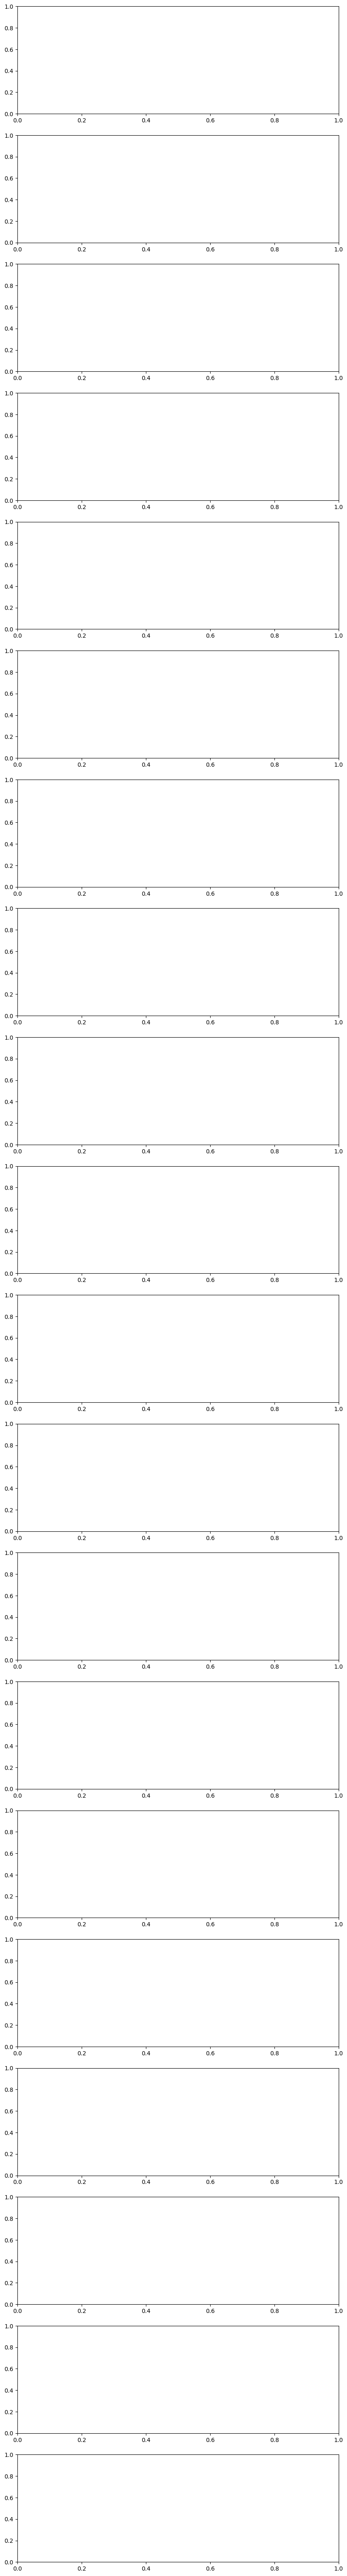

In [4]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

# -----------------------------
# Settings
# -----------------------------

muscleGroups = {'R Gluteus maximus':['glmax1_r','glmax2_r','glmax3_r'],
                        'R Gluteus medius':['glmed1_r','glmed2_r','glmed3_r'],
                        'R Gluteus minimus':['glmin1_r','glmin2_r','glmin3_r'], 
                        'R Adductor Magnus': ['addmagDist_r','addmagIsch_r','addmagMid_r','addmagProx_r'],
                        'R Biceps Femoris': ['bflh_r','bfsh_r'],
                        'R Semimembranosus': ['semimem_r'],
                        'R Semitendinosus': ['semiten_r'],
                        'R Rectus Femoris': ['recfem_r'],
                        'R Vasti':['vasint_r','vaslat_r','vasmed_r'],
                        'R Triceps Surae': ['soleus_r','gaslat_r','gasmed_r'],
                        'L Gluteus maximus':['glmax1_l','glmax2_l','glmax3_l'],
                        'L Gluteus medius':['glmed1_l','glmed2_l','glmed3_l'],
                        'L Gluteus minimus':['glmin1_l','glmin2_l','glmin3_l'], 
                        'L Adductor Magnus': ['addmagDist_l','addmagIsch_l','addmagMid_l','addmagProx_l'],
                        'L Biceps Femoris': ['bflh_l','bfsh_l'],
                        'L Semimembranosus': ['semimem_l'],
                        'L Semitendinosus': ['semiten_l'],
                        'L Rectus Femoris': ['recfem_l'],
                        'L Vasti':['vasint_l','vaslat_l','vasmed_l'],
                        'L Triceps Surae': ['soleus_l','gaslat_l','gasmed_l'],
                        }

target_muscle_groups = muscleGroups.keys()  # Process all defined muscle groups
force_source = 'so'          # 'so' or 'ceinms'

trials = {
    'Cateli': utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03', '25_03_31', 'Walking_02')),
    'Lernagopal': utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_Lernagopal', '25_03_31', 'Walking_02')),
    'GPK': utils.Analyse(os.path.join(utils.SIMULATIONS_DIR, 'Athlete_03_GPK', '25_03_31', 'Walking_02')),
}

# -----------------------------
# Helpers
# -----------------------------
def load_trial_data_for_muscle_group(trial: utils.Analyse, muscle_group: str, force_source: str = 'so'):
    muscles = muscleGroups[muscle_group]
    
    angles = utils.load_any_data_file(os.path.join(trial.path, trial.ik))
    moments = utils.load_any_data_file(os.path.join(trial.path, trial.id))
    lengths = utils.load_any_data_file(os.path.join(trial.path, trial.ma, '_MuscleAnalysis_NormalizedFiberLength.sto'))
    activations = utils.load_any_data_file(os.path.join(trial.path, trial.so_activations))
    
    if force_source == 'so':
        forces = utils.load_any_data_file(os.path.join(trial.path, trial.so_forces))
    else:
        forces = utils.load_any_data_file(os.path.join(trial.path, trial.jra_forces_ceinms))

    # Start with angles and moments
    df = angles[['time'] + ik_columns].merge(
        moments[['time'] + id_columns], on='time', how='inner'
    )
    
    # Add each muscle's data
    for muscle in muscles:
        required = {
            "length": [muscle],
            "activation": [muscle],
            "force": [muscle]
        }
        for k, cols in required.items():
            dfi = {"length": lengths, "activation": activations, "force": forces}[k]
            missing = [c for c in cols if c not in dfi.columns]
            if missing:
                raise ValueError(f"Missing {muscle} in {k}: {missing}")
        
        df = df.merge(
            lengths[['time', muscle]].rename(columns={muscle: f'{muscle}_length'}),
            on='time', how='inner'
        ).merge(
            activations[['time', muscle]].rename(columns={muscle: f'{muscle}_activation'}),
            on='time', how='inner'
        ).merge(
            forces[['time', muscle]].rename(columns={muscle: f'{muscle}_force'}),
            on='time', how='inner'
        )
    
    df = df.dropna()
    
    # Calculate total force and average activation/length for the group
    df['total_force'] = sum(df[f'{m}_force'] for m in muscles)
    df['avg_activation'] = sum(df[f'{m}_activation'] for m in muscles) / len(muscles)
    df['avg_length'] = sum(df[f'{m}_length'] for m in muscles) / len(muscles)
    
    # Calculate muscle work
    vel = np.gradient(df['avg_length'].values, df['time'].values)
    power_proxy = df['total_force'].values * vel
    muscle_work = np.trapz(np.abs(power_proxy), df['time'].values)

    return df, muscle_work


def summarize_waveform_features(df, feature_cols):
    summary = {}
    for c in feature_cols:
        v = df[c].values
        summary[f'{c}_mean'] = np.mean(v)
        summary[f'{c}_std'] = np.std(v)
        summary[f'{c}_max'] = np.max(v)
        summary[f'{c}_min'] = np.min(v)
    return summary


# -----------------------------
# Process each muscle group
# -----------------------------
n_groups = len(target_muscle_groups)
fig_ml, axes_ml = plt.subplots(n_groups, 1, figsize=(10, 4 * n_groups))
if n_groups == 1:
    axes_ml = [axes_ml]

for idx, muscle_group in enumerate(target_muscle_groups):
    print(f"\n{'='*60}")
    print(f"Processing {muscle_group}")
    print(f"{'='*60}")
    
    feature_cols = ik_columns + id_columns + ['avg_length', 'avg_activation']
    
    wave_rows = []
    work_rows = []
    
    for trial_label, trial_obj in trials.items():
        try:
            dfi, work_i = load_trial_data_for_muscle_group(trial_obj, muscle_group, force_source=force_source)
            dfi['trial_label'] = trial_label
            wave_rows.append(dfi)
            
            s = summarize_waveform_features(dfi, feature_cols)
            s['trial_label'] = trial_label
            s['muscle_work'] = work_i
            work_rows.append(s)
        except Exception as e:
            print(f"Skipping {trial_label}: {e}")
    
    wave_df = pd.concat(wave_rows, ignore_index=True)
    work_df = pd.DataFrame(work_rows)
    
    print(f"Wave samples: {len(wave_df)}")
    print(f"Trials for work model: {len(work_df)}")
    
    # Train/test split
    test_label = list(work_df['trial_label'])[-1]
    print(f"Test trial: {test_label}")
    
    train_mask_wave = wave_df['trial_label'] != test_label
    X_train_force = wave_df.loc[train_mask_wave, feature_cols]
    y_train_force = wave_df.loc[train_mask_wave, 'total_force']
    X_test_force = wave_df.loc[~train_mask_wave, feature_cols]
    y_test_force = wave_df.loc[~train_mask_wave, 'total_force']
    
    force_model = RandomForestRegressor(n_estimators=400, max_depth=14, random_state=42, n_jobs=-1)
    force_model.fit(X_train_force, y_train_force)
    y_pred_force = force_model.predict(X_test_force)
    
    rmse_force = np.sqrt(mean_squared_error(y_test_force, y_pred_force))
    r2_force = r2_score(y_test_force, y_pred_force)
    print(f"[Force] RMSE={rmse_force:.3f}, R²={r2_force:.3f}")
    
    # Work model
    work_feature_cols = [c for c in work_df.columns if c not in ['trial_label', 'muscle_work']]
    train_mask_work = work_df['trial_label'] != test_label
    
    X_train_work = work_df.loc[train_mask_work, work_feature_cols]
    y_train_work = work_df.loc[train_mask_work, 'muscle_work']
    X_test_work = work_df.loc[~train_mask_work, work_feature_cols]
    y_test_work = work_df.loc[~train_mask_work, 'muscle_work']
    
    work_model = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
    work_model.fit(X_train_work, y_train_work)
    y_pred_work = work_model.predict(X_test_work)
    
    if len(y_test_work) > 0:
        rmse_work = np.sqrt(mean_squared_error(y_test_work, y_pred_work))
        print(f"[Work] True={y_test_work.values[0]:.4f}, Pred={y_pred_work[0]:.4f}, RMSE={rmse_work:.4f}")
    
    # Plot
    test_wave = wave_df.loc[~train_mask_wave, ['time', 'total_force']].copy()
    test_wave['force_pred'] = y_pred_force
    
    axes_ml[idx].plot(test_wave['time'], test_wave['total_force'], label='True force', linewidth=2)
    axes_ml[idx].plot(test_wave['time'], test_wave['force_pred'], '--', label='Predicted force', linewidth=2)
    axes_ml[idx].set_title(f'{muscle_group} force prediction ({test_label})')
    axes_ml[idx].set_xlabel('Time (s)')
    axes_ml[idx].set_ylabel('Force')
    axes_ml[idx].legend()

plt.tight_layout()
ml_save_path = os.path.join(results_dir, f"ml_force_work_muscle_groups_{trialName}.png")
plt.savefig(ml_save_path, dpi=300)
print(f"\nSaved ML figure: {ml_save_path}")

# Create summary excel file

In [ ]:
import os
import pandas as pd
import utils 

# --- Configuration ---
simulations_dir = utils.SIMULATIONS_DIR
results_file = os.path.join(utils.RESULTS_DIR, 'summary_data.csv')

target_sessions = ['25_03_31'] 
trial_prefixes = ['Squat_bw', 'Squat_35kg', 'Walking']
variables_of_interest = ['ik', 'id', 'so_forces']

subjects = [d for d in os.listdir(simulations_dir) if os.path.isdir(os.path.join(simulations_dir, d))]

# Master list to hold the final merged dataframes for each trial
all_trials_data = []

# --- Main Loop ---
for subject in subjects:
    subject_path = os.path.join(simulations_dir, subject)
    available_sessions = target_sessions if target_sessions else os.listdir(subject_path)

    for session in available_sessions:
        session_path = os.path.join(subject_path, session)
        
        if not os.path.exists(session_path):
            continue

        try:
            trials = os.listdir(session_path)
        except NotADirectoryError:
            continue

        for trial in trials:
            if not any(trial.startswith(prefix) for prefix in trial_prefixes):
                continue

            trial_path = os.path.join(session_path, trial)
            
            try:
                analyse = utils.Analyse(trial_path)
            except Exception as e:
                print(f"Skipping {trial}: {e}")
                continue

            print(f'Processing: {subject} | {session} | {trial}')

            # 1. Initialize a container for THIS specific trial
            # We will merge all variables for this trial into this single DataFrame
            current_trial_df = None

            for var in variables_of_interest:
                filename = getattr(analyse, var, None)
                if filename is None:
                    continue

                full_file_path = os.path.join(trial_path, filename)
                if not os.path.exists(full_file_path):
                    continue

                try:
                    df = utils.load_any_data_file(full_file_path)
                except Exception as e:
                    print(f"Error loading {filename}: {e}")
                    continue

                # Ensure 'time' is a column (crucial for merging)
                if df.index.name == 'time' or 'time' in df.index.names:
                    df = df.reset_index()

                # 2. Merge logic
                if current_trial_df is None:
                    # First file loaded for this trial, start the DataFrame
                    current_trial_df = df
                else:
                    # Subsequent files: Merge columns based on 'time'
                    # 'outer' join ensures we don't lose data if time stamps differ slightly
                    current_trial_df = pd.merge(current_trial_df, df, on='time', how='outer')

            # 3. Finalize the Trial DataFrame
            if current_trial_df is not None:

                current_trial_df = utils.time_normalise_df(current_trial_df)
                
                # Add Metadata columns
                current_trial_df['subject'] = subject
                current_trial_df['session'] = session
                current_trial_df['trial'] = trial

                # Reorder columns: Metadata first, then time, then everything else
                cols = list(current_trial_df.columns)
                # Remove metadata/time from the list so we can re-insert them at the front
                for col_name in ['subject', 'session', 'trial', 'time']:
                    if col_name in cols:
                        cols.remove(col_name)
                
                # Construct new order
                final_order = ['subject', 'session', 'trial', 'time'] + cols
                current_trial_df = current_trial_df[final_order]

                # Add to master list
                all_trials_data.append(current_trial_df)

# --- Final Assembly ---
print("Concatenating all trials...")

if all_trials_data:
    summary_df = pd.concat(all_trials_data, ignore_index=True)
    summary_df.to_csv(results_file, index=False)
    print(f"Success! Summary data saved to: {results_file}")
    print(f"Total rows: {len(summary_df)}")
else:
    print("No data was found matching your criteria.")

## load results and plot

In [ ]:
# load summary data
summary_df = pd.read_csv(os.path.join(utils.RESULTS_DIR, 'summary_data.csv'))

# find all trials who start with similar names and create groups
# Extract trial base name (remove numeric suffix) to group similar trials
summary_df['trial_base'] = summary_df['trial'].str.replace(r'_\d+$', '', regex=True)

# Group trials by subject, session, and trial_base
trial_groups = summary_df.groupby(['subject', 'session', 'trial_base'])

columns_of_interest = ['hip_flexion_r_moment', 'hip_flexion_l_moment']
# plot line plots for these columns separated by subject, session, and trial
import matplotlib.pyplot as plt

for col_name in columns_of_interest:
    plt.figure(figsize=(10, 6))
    for (subject, session, trial), group in summary_df.groupby(['subject', 'session', 'trial']):
        plt.plot(group['time'], group[col_name], label=f'{subject} | {session} | {trial}')
    
    plt.title(f'Time Series of {col_name}')
    plt.xlabel('Time (s)')
    plt.ylabel(col_name)
    plt.legend()
    plt.grid()
    plt.show()

plt.show()

In [ ]:
# load summary data
summary_df = pd.read_csv(os.path.join(utils.RESULTS_DIR, 'summary_data.csv'))

# Extract trial base name (remove numeric suffix) to group similar trials
summary_df['trial_base'] = summary_df['trial'].str.replace(r'_\d+[a-zA-Z]*$', '', regex=True)

# move trial_base column to the front
cols = list(summary_df.columns)

# save updated summary data with trial_base
summary_df.to_csv(os.path.join(utils.RESULTS_DIR, 'summary_data_with_trial_base.csv'), index=False)

# Get unique trial bases
trial_bases = summary_df['trial_base'].unique()

# Define columns of interest
columns_of_interest = ['hip_flexion_r_moment', 'hip_flexion_l_moment', 'knee_angle_r_moment', 'knee_angle_l_moment']

# Create subplots for each trial base
for col_name in columns_of_interest:
    fig, axes = plt.subplots(1, len(trial_bases), figsize=(6*len(trial_bases), 5))
    
    # Handle single trial base case
    if len(trial_bases) == 1:
        axes = [axes]
    
    for idx, trial_base in enumerate(trial_bases):
        ax = axes[idx]
        
        # Filter data for this trial base
        trial_data = summary_df[summary_df['trial_base'] == trial_base]
        
        # Group by subject and session
        for (subject, session), group in trial_data.groupby(['subject', 'session']):
            # Calculate mean and std across time-normalized trials
            mean_curve = group.groupby('time')[col_name].mean()
            std_curve = group.groupby('time')[col_name].std()
            
            # Plot mean line
            ax.plot(mean_curve.index, mean_curve.values, label=f'{subject} | {session}', linewidth=2)
            
            # Plot standard deviation as shaded area
            ax.fill_between(mean_curve.index, 
                           mean_curve.values - std_curve.values, 
                           mean_curve.values + std_curve.values, 
                           alpha=0.2)
        
        ax.set_title(f'{trial_base} - {col_name}')
        ax.set_xlabel('Time (normalized)')
        ax.set_ylabel(col_name)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    save_path = os.path.join(utils.RESULTS_DIR, f'{col_name}_comparison.png')
    plt.savefig(save_path, dpi=150)
    print(f"Saved: {save_path}")
    plt.show()
